# Trabajo 1 - Econometría II 2026-1S
## Modelación ARIMA del Precio Internacional del Aluminio

**Integrantes:** Santiago Vargas, Dilan Tovar, Maria Orjuela

**Profesores:** Milena Hoyos, Luis Luna, German Rodriguez

**Universidad Nacional de Colombia - Facultad de Ciencias Económicas**

---

### Descripción

Este notebook aplica la metodología Box-Jenkins para modelar el **precio internacional del aluminio** (USD por tonelada métrica), con datos del **Fondo Monetario Internacional (FMI)** para el período marzo 2016 a marzo 2026 (121 observaciones mensuales).

### Motivación económica

El aluminio es uno de los metales industriales más utilizados a nivel global. Su importancia económica radica en su papel central en sectores estratégicos:

- **Construcción e infraestructura**: edificios, ventanería, estructuras.
- **Transporte**: automotriz, aeroespacial, ferroviario.
- **Envasado y empaques**: latas, papel aluminio, contenedores.
- **Transición energética**: paneles solares, redes eléctricas, vehículos eléctricos (donde reemplaza al acero por su menor peso).

A diferencia de otros metales industriales, el aluminio tiene una **dinámica de precios bien comportada** que lo hace particularmente adecuado para el modelado ARIMA: presenta tendencia, volatilidad moderada y ausencia de estacionalidad anual marcada. Modelar su evolución resulta relevante para la planeación de costos de manufactura, decisiones de inversión y análisis del ciclo industrial global.

### Estructura del notebook

0. **Configuración** — Importación de librerías y rutas relativas.
1. **Datos** — Lectura del CSV del FMI y preparación de la serie.
2. **Análisis exploratorio** — Visualización y transformación logarítmica.
3. **Identificación** — FAC, FACP y pruebas de raíz unitaria.
4. **Estimación** — Ajuste de modelos ARIMA candidatos.
5. **Validación** — Diagnóstico de residuos.
6. **Pronóstico** — Proyección a 10 meses.

### Fuente de los datos

Fondo Monetario Internacional (FMI), Primary Commodity Prices, serie *Global price of Aluminum* (PALUMUSDM), obtenida vía FRED (Federal Reserve Bank of St. Louis). Unidades: dólares estadounidenses por tonelada métrica, no ajustado estacionalmente.

Archivo original: `data/raw/PALUMUSDM.csv`

## Bloque 0: Configuración

Importación de paquetes y definición de rutas relativas usando `pathlib`. Esto garantiza que el código corra en cualquier computador sin modificar manualmente las rutas.

In [1]:
# %% Importación de paquetes ============================

# Trabajar con rutas relativas en python
from pathlib import Path

# Módulos de numpy, pandas, matplotlib y scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera, probplot, norm

# Módulos de statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

# Configuración estética de matplotlib
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Paquetes importados correctamente.")

Paquetes importados correctamente.


In [2]:
# %% Definición de rutas relativas =====================

notebook_path = Path.cwd()
if notebook_path.name == "notebooks":
    PROJECT_ROOT = notebook_path.parent
else:
    PROJECT_ROOT = notebook_path

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES = PROJECT_ROOT / "outputs" / "tables"

for d in [DATA_PROCESSED, FIGURES, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto:  {PROJECT_ROOT}")
print(f"Datos crudos:       {DATA_RAW}")
print(f"Datos procesados:   {DATA_PROCESSED}")
print(f"Figuras:            {FIGURES}")
print(f"Tablas:             {TABLES}")

Raíz del proyecto:  c:\poster-main\poster
Datos crudos:       c:\poster-main\poster\data\raw
Datos procesados:   c:\poster-main\poster\data\processed
Figuras:            c:\poster-main\poster\outputs\figures
Tablas:             c:\poster-main\poster\outputs\tables


## Bloque 1: Carga y preparación de la serie

El archivo del FMI tiene una estructura simple con dos columnas:
- `observation_date`: fecha mensual (primer día de cada mes).
- `PALUMUSDM`: precio del aluminio en USD por tonelada métrica.

Vamos a:
1. Leer el CSV.
2. Renombrar columnas a nombres claros.
3. Construir el índice temporal mensual.
4. Guardar la serie como CSV procesado en `data/processed/aluminio_precio.csv`.

In [3]:
# %% Lectura del CSV del FMI ============================

ruta_csv_raw = DATA_RAW / "PALUMUSDM.csv"
print(f"Leyendo: {ruta_csv_raw}")

df_raw = pd.read_csv(ruta_csv_raw)

print(f"Forma del DataFrame: {df_raw.shape}")
print(f"\nColumnas: {list(df_raw.columns)}")
print(f"\nPrimeras filas:")
print(df_raw.head())
print(f"\nÚltimas filas:")
print(df_raw.tail())

Leyendo: c:\poster-main\poster\data\raw\PALUMUSDM.csv
Forma del DataFrame: (121, 2)

Columnas: ['observation_date', 'PALUMUSDM']

Primeras filas:
  observation_date    PALUMUSDM
0       2016-03-01  1531.011905
1       2016-04-01  1571.226190
2       2016-05-01  1550.625000
3       2016-06-01  1593.506818
4       2016-07-01  1629.047619

Últimas filas:
    observation_date    PALUMUSDM
116       2025-11-01  2819.061500
117       2025-12-01  2875.897727
118       2026-01-01  3133.982727
119       2026-02-01  3065.188500
120       2026-03-01  3372.952727


In [4]:
# %% Construcción de la serie de tiempo =================

df = df_raw.rename(columns={
    "observation_date": "fecha",
    "PALUMUSDM": "precio_aluminio"
})

df["fecha"] = pd.to_datetime(df["fecha"])

aluminio_serie = df.set_index("fecha")["precio_aluminio"]
aluminio_serie = aluminio_serie.asfreq("MS")

print(f"Observaciones: {len(aluminio_serie)}")
print(f"Rango temporal: {aluminio_serie.index.min().strftime('%Y-%m')} a {aluminio_serie.index.max().strftime('%Y-%m')}")
print(f"\n¿Hay valores faltantes?: {aluminio_serie.isna().sum()}")
print(f"\nPrimeras 5 observaciones:")
print(aluminio_serie.head())
print(f"\nÚltimas 5 observaciones:")
print(aluminio_serie.tail())

Observaciones: 121
Rango temporal: 2016-03 a 2026-03

¿Hay valores faltantes?: 0

Primeras 5 observaciones:
fecha
2016-03-01    1531.011905
2016-04-01    1571.226190
2016-05-01    1550.625000
2016-06-01    1593.506818
2016-07-01    1629.047619
Freq: MS, Name: precio_aluminio, dtype: float64

Últimas 5 observaciones:
fecha
2025-11-01    2819.061500
2025-12-01    2875.897727
2026-01-01    3133.982727
2026-02-01    3065.188500
2026-03-01    3372.952727
Freq: MS, Name: precio_aluminio, dtype: float64


In [5]:
# %% Estadísticas descriptivas =========================

print("Estadísticas descriptivas del precio del aluminio (USD/tonelada):")
print(aluminio_serie.describe().round(2))
print(f"\nValor mínimo: {aluminio_serie.min():.2f} USD/ton ({aluminio_serie.idxmin().strftime('%b %Y')})")
print(f"Valor máximo: {aluminio_serie.max():.2f} USD/ton ({aluminio_serie.idxmax().strftime('%b %Y')})")

Estadísticas descriptivas del precio del aluminio (USD/tonelada):
count     121.00
mean     2202.96
std       439.95
min      1459.93
25%      1853.72
50%      2184.75
75%      2497.61
max      3498.37
Name: precio_aluminio, dtype: float64

Valor mínimo: 1459.93 USD/ton (Apr 2020)
Valor máximo: 3498.37 USD/ton (Mar 2022)


In [6]:
# %% Guardado del CSV procesado ========================

ruta_csv_proc = DATA_PROCESSED / "aluminio_precio.csv"

aluminio_df = aluminio_serie.reset_index()
aluminio_df.columns = ["fecha", "precio_aluminio"]
aluminio_df.to_csv(ruta_csv_proc, index=False)

print(f"CSV procesado guardado en: {ruta_csv_proc}")
print(f"Tamaño: {ruta_csv_proc.stat().st_size} bytes")
print(f"\nPrimeras 3 filas:")
print(aluminio_df.head(3))

CSV procesado guardado en: c:\poster-main\poster\data\processed\aluminio_precio.csv
Tamaño: 3445 bytes

Primeras 3 filas:
       fecha  precio_aluminio
0 2016-03-01      1531.011905
1 2016-04-01      1571.226190
2 2016-05-01      1550.625000


## Bloque 2: Análisis exploratorio
Para series de precios de commodities, la práctica estándar es trabajar en **logaritmos**: la transformación

$$y_t = \log(P_t)$$

convierte cambios proporcionales en cambios absolutos, estabiliza la varianza cuando ésta crece con el nivel, y garantiza que los pronósticos al re-exponenciar sean siempre positivos (un precio negativo no tendría sentido económico).

Adicionalmente, la primera diferencia del logaritmo:

$$\Delta y_t = \log(P_t) - \log(P_{t-1}) \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$

aproxima el **retorno porcentual mensual** del precio, una magnitud económicamente interpretable y comparable entre series.

Esta sección evalúa la pertinencia de la transformación logarítmica y diagnostica visualmente la presencia o ausencia de estacionalidad.

### 2.1 Carga del CSV procesado

Recargamos la serie desde el CSV procesado para que este bloque sea independiente del Bloque 1 (reproducibilidad).

In [7]:
# %% Carga del CSV procesado ===========================

ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"

aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")

print(f"Serie cargada: {len(aluminio_serie)} observaciones")
print(f"Rango temporal: {aluminio_serie.index.min().strftime('%Y-%m')} a {aluminio_serie.index.max().strftime('%Y-%m')}")

Serie cargada: 121 observaciones
Rango temporal: 2016-03 a 2026-03


### 2.2 Visualización de la serie en niveles

Inspeccionamos la trayectoria del precio en su escala original (USD por tonelada métrica). En esta gráfica buscamos identificar:

- **Tendencia de largo plazo**: ¿el precio crece, decrece o se mantiene estable?
- **Episodios extremos**: caídas o subidas atípicas que puedan corresponder a eventos económicos identificables.
- **Patrones cíclicos**: oscilaciones regulares que sugieran ciclos económicos o estacionalidad.
- **Heterocedasticidad visible**: ¿las fluctuaciones cambian de magnitud con el nivel del precio?

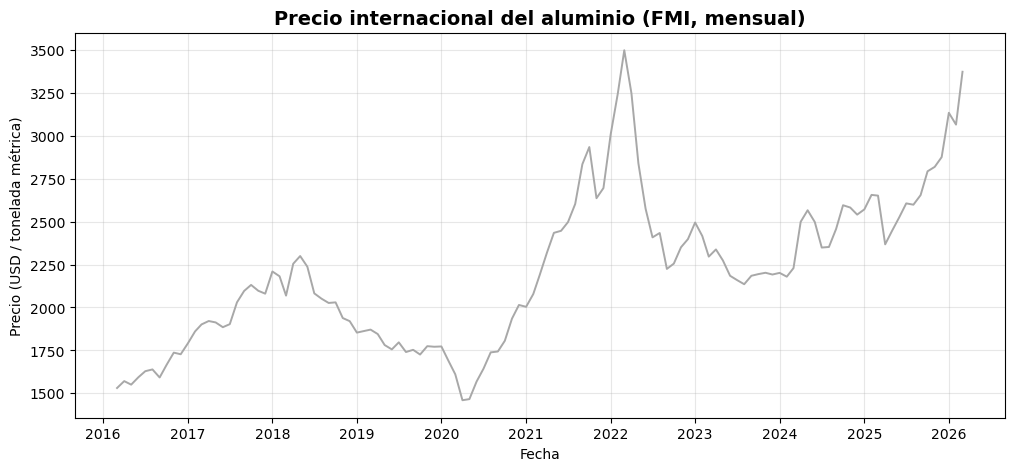

Figura guardada en: c:\poster-main\poster\outputs\figures\01_serie_niveles.png


In [8]:
# %% Gráfico 1: Serie en niveles =======================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(aluminio_serie.index, aluminio_serie.values, color="#a8a8a8", linewidth=1.4)
ax.set_title("Precio internacional del aluminio (FMI, mensual)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD / tonelada métrica)")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "01_serie_niveles.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

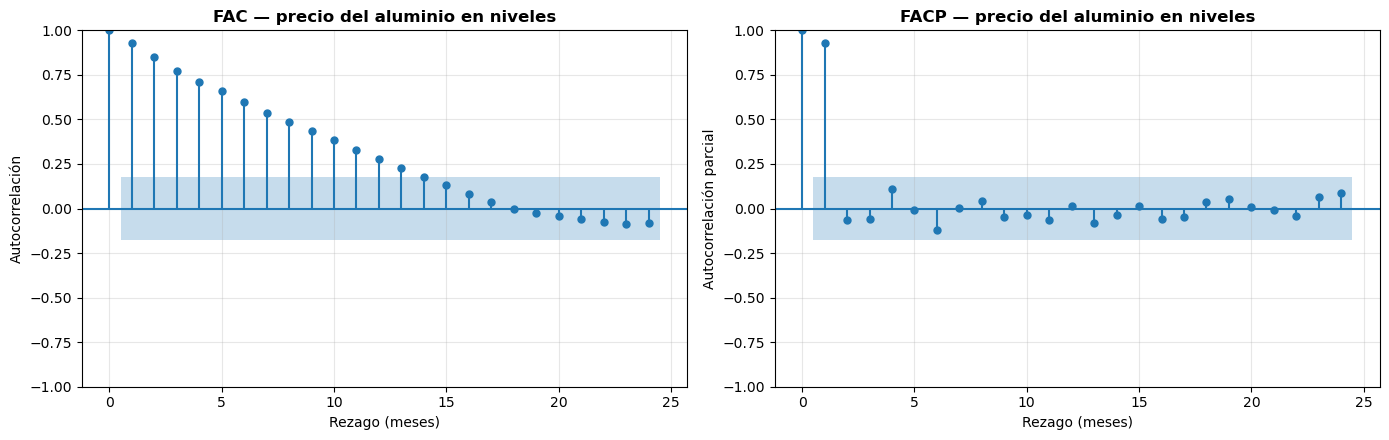

Figura guardada en: c:\poster-main\poster\outputs\figures\04_fac_facp_niveles.png


In [9]:
# %% FAC y FACP de la serie en niveles =================

# Para una serie con raíz unitaria esperamos:
#  - FAC con decaimiento LENTO hacia cero (firma de no estacionariedad).
#  - FACP con un pico fuerte en el rezago 1 (cercano a 1) y el resto ~0.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(aluminio_serie, lags=24, alpha=0.05, bartlett_confint=False, ax=axes[0])
axes[0].set_title("FAC — precio del aluminio en niveles", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")
axes[0].set_ylabel("Autocorrelación")

plot_pacf(aluminio_serie, lags=24, alpha=0.05, ax=axes[1])
axes[1].set_title("FACP — precio del aluminio en niveles", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")
axes[1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()
ruta_fig = FIGURES / "04_fac_facp_niveles.png"
plt.savefig(ruta_fig)
plt.show()
print(f"Figura guardada en: {ruta_fig}")

Por la gráfica nos podemos dar cuenta de muchas cosas importantes. La primera, es que claramente la serie tiene tendencia estocástica, parece una caminata aleatoria. Asi que claramente no es estacionaria, sería conveniente aplicarle una diferencia. Tiene una subida abrupta desde el 2020 Marzo, asociamos esta tendencia a la crisis enérgetica europea. Por lo que podemos observar, también se ve como una serie heteroscedastica, entonces seria conveniente aplicarle logaritmo a la serie. No tiene estacionalidad marcada.

### 2.3 Transformación logarítmica

Aplicamos la transformación

$$y_t = \log(P_t)$$

y graficamos para comparar visualmente con la serie en niveles. En commodities, la transformación logarítmica es la convención estándar porque:

1. **Estabiliza la varianza** cuando ésta crece proporcionalmente con el nivel del precio.
2. **Linealiza el crecimiento exponencial** en una tendencia aproximadamente lineal.
3. **Garantiza pronósticos positivos**: al exponenciar el pronóstico ($\hat{P}_t = e^{\hat{y}_t}$), los intervalos de confianza son siempre positivos y asimétricos, como corresponde económicamente a un precio.
4. **Permite interpretar diferencias como cambios porcentuales**: $\Delta \log(P_t) \approx \%$ cambio cuando este es pequeño.

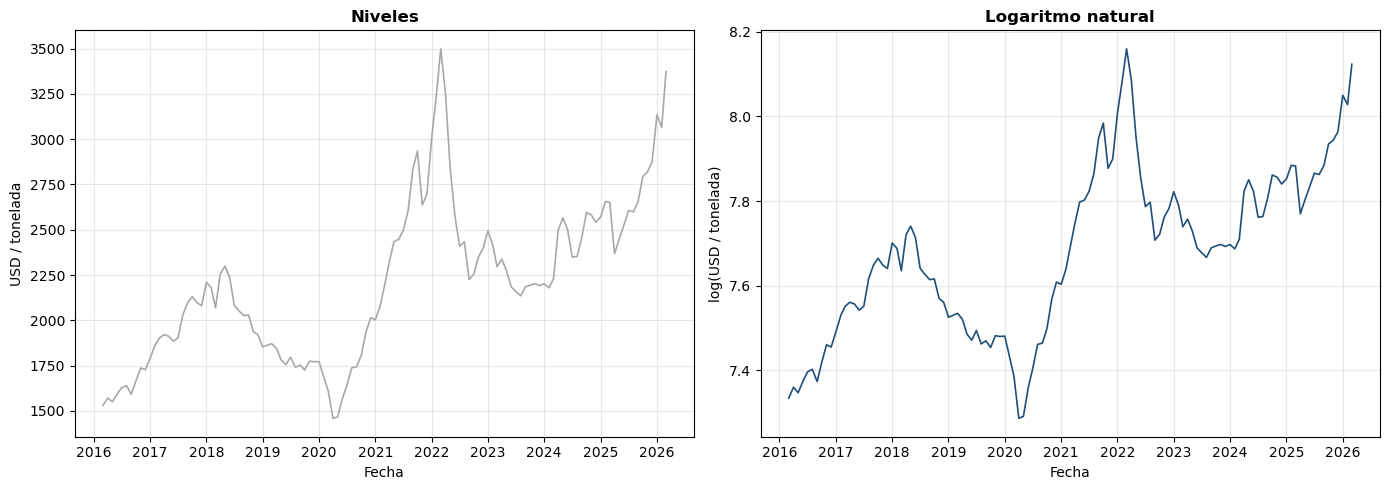

Figura guardada en: c:\poster-main\poster\outputs\figures\02_niveles_vs_log.png

Log-precio: media = 7.6783, std = 0.1966
Rango log: [7.2861, 8.1601]


In [10]:
# %% Transformación logarítmica =========================

aluminio_log = np.log(aluminio_serie)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(aluminio_serie.index, aluminio_serie.values, color="#a8a8a8", linewidth=1.2)
axes[0].set_title("Niveles", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("USD / tonelada")
axes[0].grid(True, alpha=0.3)

axes[1].plot(aluminio_log.index, aluminio_log.values, color="#1f4e79", linewidth=1.2)
axes[1].set_title("Logaritmo natural", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("log(USD / tonelada)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

ruta_fig = FIGURES / "02_niveles_vs_log.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")
print(f"\nLog-precio: media = {aluminio_log.mean():.4f}, std = {aluminio_log.std():.4f}")
print(f"Rango log: [{aluminio_log.min():.4f}, {aluminio_log.max():.4f}]")

Nota interpretativa: dado que el precio del aluminio recorre aproximadamente un rango de 1,500 a 3,400 USD (factor de ~2.3x), el recorrido logarítmico es relativamente pequeño (~0.8 unidades). Esto significa que la forma de la curva en log se ve similar a la curva en niveles, pero la transformación sí cumple su función de estabilizar la varianza relativa y de garantizar pronósticos positivos.

### 2.4 Retornos logarítmicos mensuales

Calculamos la primera diferencia del log-precio:

$$r_t = \Delta \log(P_t) = \log(P_t) - \log(P_{t-1})$$

Esta cantidad representa el **retorno logarítmico mensual** del aluminio. Cuando el cambio es pequeño (típicamente menos de 10%), se aproxima al retorno porcentual:

$$r_t \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$

Si los retornos $r_t$ fluctúan alrededor de una constante con varianza estable y sin patrones sistemáticos, entonces la serie del log-precio es **integrada de orden 1** ($I(1)$), y un modelo ARIMA con $d = 1$ sobre el log-precio resultaría apropiado.

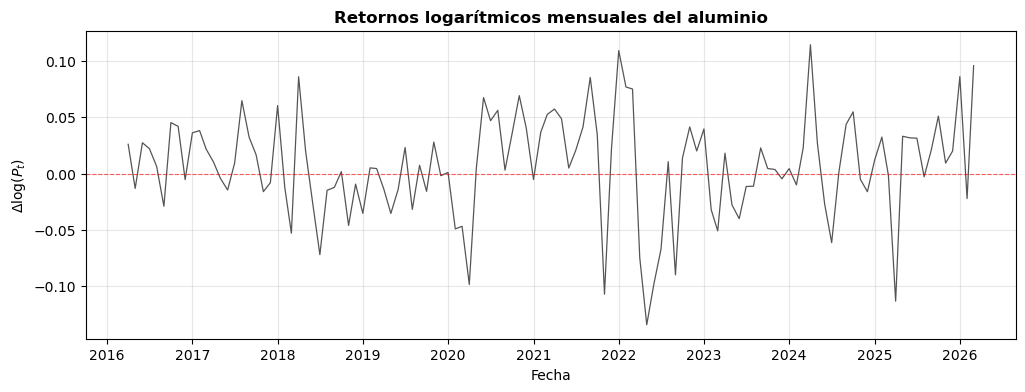

Figura guardada en: c:\poster-main\poster\outputs\figures\03_retornos_log.png

Media de retornos:     0.00658 (0.66% mensual)
Desviación estándar:   0.04542
Retorno mínimo:        -0.1341 (May 2022)
Retorno máximo:        0.1142 (Apr 2024)


In [11]:
# %% Retornos logarítmicos mensuales ===================

retornos_log = aluminio_log.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(retornos_log.index, retornos_log.values, color="#555555", linewidth=0.9)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Retornos logarítmicos mensuales del aluminio",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta \log(P_t)$")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "03_retornos_log.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")
print(f"\nMedia de retornos:     {retornos_log.mean():.5f} ({retornos_log.mean()*100:.2f}% mensual)")
print(f"Desviación estándar:   {retornos_log.std():.5f}")
print(f"Retorno mínimo:        {retornos_log.min():.4f} ({retornos_log.idxmin().strftime('%b %Y')})")
print(f"Retorno máximo:        {retornos_log.max():.4f} ({retornos_log.idxmax().strftime('%b %Y')})")

### 2.5 Caracterización numérica de la serie

Síntesis de las características empíricas del precio del aluminio y sus retornos logarítmicos para tener un panorama completo antes de pasar a la identificación formal del modelo.

In [12]:
# %% Caracterización de la serie =======================

print("=" * 65)
print("CARACTERIZACIÓN DE LA SERIE DEL PRECIO DEL ALUMINIO")
print("=" * 65)
print(f"\nNúmero de observaciones:    {len(aluminio_serie)}")
print(f"Frecuencia:                 Mensual")
print(f"Periodo:                    {aluminio_serie.index.min().strftime('%b %Y')} - {aluminio_serie.index.max().strftime('%b %Y')}")
print(f"\nEn niveles (USD/tonelada):")
print(f"  Media:                    {aluminio_serie.mean():.2f}")
print(f"  Mediana:                  {aluminio_serie.median():.2f}")
print(f"  Desviación estándar:      {aluminio_serie.std():.2f}")
print(f"  Mínimo:                   {aluminio_serie.min():.2f} ({aluminio_serie.idxmin().strftime('%b %Y')})")
print(f"  Máximo:                   {aluminio_serie.max():.2f} ({aluminio_serie.idxmax().strftime('%b %Y')})")
print(f"  Coef. de variación:       {(aluminio_serie.std()/aluminio_serie.mean())*100:.1f}%")
print(f"\nEn logaritmos:")
print(f"  Media:                    {aluminio_log.mean():.4f}")
print(f"  Desviación estándar:      {aluminio_log.std():.4f}")
print(f"  Rango:                    [{aluminio_log.min():.4f}, {aluminio_log.max():.4f}]")
print(f"\nRetornos logarítmicos mensuales:")
print(f"  Media:                    {retornos_log.mean()*100:.3f}% mensual")
print(f"  Volatilidad (std):        {retornos_log.std()*100:.2f}% mensual")
print(f"  Volatilidad anualizada:   {retornos_log.std()*np.sqrt(12)*100:.2f}%")

CARACTERIZACIÓN DE LA SERIE DEL PRECIO DEL ALUMINIO

Número de observaciones:    121
Frecuencia:                 Mensual
Periodo:                    Mar 2016 - Mar 2026

En niveles (USD/tonelada):
  Media:                    2202.96
  Mediana:                  2184.75
  Desviación estándar:      439.95
  Mínimo:                   1459.93 (Apr 2020)
  Máximo:                   3498.37 (Mar 2022)
  Coef. de variación:       20.0%

En logaritmos:
  Media:                    7.6783
  Desviación estándar:      0.1966
  Rango:                    [7.2861, 8.1601]

Retornos logarítmicos mensuales:
  Media:                    0.658% mensual
  Volatilidad (std):        4.54% mensual
  Volatilidad anualizada:   15.73%


### 2.6 Conclusiones del análisis exploratorio

A partir del análisis visual y descriptivo de la serie del precio del aluminio:

**1. Sobre la transformación logarítmica:**

Se adopta la transformación $y_t = \log(P_t)$ por las razones estándar en commodities: estabilización de varianza, interpretación de diferencias como cambios porcentuales, y garantía de pronósticos positivos. Aunque el recorrido logarítmico de esta serie es moderado (~0.8 unidades), la transformación no introduce distorsión y mantiene la coherencia con la convención de la literatura financiera.

**2. Sobre la estacionariedad:**

La serie en niveles presenta una **tendencia clara de largo plazo** (creciente desde 2016, con un episodio de alta volatilidad en 2021-2022 correspondiente a la crisis energética europea, y estabilización posterior). Visualmente, **no es estacionaria**: la media cambia en el tiempo. Los retornos logarítmicos, en cambio, fluctúan alrededor de cero con varianza aparentemente estable, sugiriendo que la serie del log-precio es **integrada de orden 1** ($I(1)$), lo cual se verificará formalmente en el Bloque 3 mediante las pruebas ADF y DF.

**3. Plan para los siguientes bloques:**

| Decisión metodológica | Justificación |
|---|---|
| Transformación logarítmica | Estándar en commodities |
| Modelo ARIMA (no SARIMA) | Ausencia de estacionalidad clara |
| Diferenciación regular $d = 1$ (por verificar) | Tendencia visible en niveles |
| Sin dummy de intervención | Sin shocks estructurales prolongados visibles |

En el **Bloque 3** confirmaremos formalmente la necesidad de diferenciación mediante pruebas de raíz unitaria, e identificaremos los órdenes $p$ y $q$ tentativos a partir de las funciones FAC y FACP de la serie estacionaria.

## Bloque 3: Identificación (Etapa 1 de Box-Jenkins)

La etapa de identificación busca determinar los **órdenes $(p, d, q)$** del modelo ARIMA que mejor describe el comportamiento de la serie. Se compone de tres pasos:

1. **Determinar $d$**: el grado de diferenciación necesario para que la serie sea estacionaria.
2. **Determinar $p$ y $q$**: los órdenes autorregresivo y de media móvil, a partir de la FAC y FACP de la serie ya estacionaria.
3. **Proponer modelos candidatos** que se estimarán y validarán en bloques posteriores.

**Notación (siguiendo Enders, Cap. 2):**

- $a_i$: coeficientes autorregresivos (AR).
- $\beta_i$: coeficientes de media móvil (MA).
- $L$: operador de rezago, $Ly_t = y_{t-1}$.
- $y_t = \log(P_t)$: trabajamos sobre el logaritmo natural del precio del aluminio.

**Nota:** dado que el aluminio no exhibe estacionalidad anual (verificado en el Bloque 2), no se incluye componente estacional. El modelo será un ARIMA simple, no SARIMA.

### 3.1 Carga de la serie y transformación logarítmica

Recargamos la serie procesada y aplicamos la transformación logarítmica, base de todo el análisis posterior.

In [13]:
# %% Carga de la serie y transformación log =============

ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"
aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")

# Transformación logarítmica
aluminio_log = np.log(aluminio_serie)

print(f"Serie cargada: {len(aluminio_log)} observaciones")
print(f"Rango: {aluminio_log.index.min().strftime('%Y-%m')} a {aluminio_log.index.max().strftime('%Y-%m')}")

Serie cargada: 121 observaciones
Rango: 2016-03 a 2026-03


### 3.2 Marco teórico de las pruebas Dickey-Fuller

Para determinar si una serie es estacionaria utilizamos las pruebas de **Dickey-Fuller (DF)** y **Dickey-Fuller Aumentada (ADF)**, las más estándar en la literatura econométrica.

#### Prueba Dickey-Fuller (DF) básica


$$\Delta y_t = \gamma\, y_{t-1} + \varepsilon_t, \quad \text{donde } \gamma = a_1 - 1$$

La hipótesis de raíz unitaria $a_1 = 1$ se traduce en $\gamma = 0$. Así:

$$
\begin{aligned}
H_0:\ &\gamma = 0 \quad \Rightarrow \quad \text{la serie tiene raíz unitaria (no estacionaria)} \\
H_1:\ &\gamma < 0 \quad \Rightarrow \quad \text{la serie es estacionaria}
\end{aligned}
$$

#### Prueba Dickey-Fuller Aumentada (ADF)

La DF básica asume que los errores $\varepsilon_t$ son **ruido blanco**. Si la serie tiene dinámica adicional (autocorrelación de orden mayor que 1), esa autocorrelación se "filtra" a los errores y la prueba pierde validez.

La **versión aumentada (ADF)** corrige este problema agregando rezagos de la diferencia como regresores:

$$\Delta y_t = \gamma\, y_{t-1} + \sum_{i=1}^{p} \delta_i\, \Delta y_{t-i} + \varepsilon_t$$

Los términos $\Delta y_{t-i}$ absorben la autocorrelación residual, dejando los errores como ruido blanco. La hipótesis nula sigue siendo $\gamma = 0$ y el estadístico se interpreta igual.

**¿Cuántos rezagos $p$ se incluyen?** Hay varios criterios; el más común es usar el AIC o BIC para elegir el $p$ óptimo. En la práctica, `statsmodels` selecciona automáticamente el número de rezagos mediante criterios de información.

#### Especificaciones de la regresión auxiliar

Tanto DF como ADF pueden incluir términos deterministas en la regresión auxiliar:

| Especificación | Regresión auxiliar | ¿Cuándo usar? |
|---|---|---|
| **Sin intercepto ni tendencia** | $\Delta y_t = \gamma y_{t-1} + \cdots$ | Series sin tendencia visible ni media distinta de cero. |
| **Con intercepto** | $\Delta y_t = c + \gamma y_{t-1} + \cdots$ | Series sin tendencia pero con media no nula. |
| **Con intercepto y tendencia** | $\Delta y_t = c + \beta t + \gamma y_{t-1} + \cdots$ | Series con tendencia determinística visible. |

Cada especificación tiene **valores críticos distintos** (más negativos en orden creciente de complejidad). Por defecto, `statsmodels` usa la especificación con intercepto.

### 3.3 Implementación de DF y ADF

Definimos una función que ejecuta tanto la **DF básica** (sin rezagos aumentados) como la **ADF** (con selección automática de rezagos por AIC) y reporta los resultados con interpretación.

In [14]:
# %% Función auxiliar para tests Dickey-Fuller ==========

def test_dickey_fuller(serie, nombre="", alpha=0.05):
    """
    Aplica las pruebas Dickey-Fuller (DF) y Dickey-Fuller Aumentada (ADF)
    a una serie temporal, e imprime los resultados con interpretación.
    
    DF: maxlag=0 (sin rezagos aumentados, asume errores ruido blanco).
    ADF: maxlag por defecto (selección automática vía AIC).
    """
    serie_limpia = serie.dropna()
    
    print(f"\n{'=' * 60}")
    print(f"TESTS DICKEY-FULLER — {nombre}")
    print(f"{'=' * 60}")
    print(f"Hipótesis nula (H₀): la serie tiene raíz unitaria (NO estacionaria).")
    print(f"Hipótesis alternativa (H₁): la serie es estacionaria.")
    print(f"Decisión: si p-valor < {alpha}, se rechaza H₀.")
    
    # --- Dickey-Fuller básica (sin rezagos aumentados) ---
    df_result = adfuller(serie_limpia, maxlag=0, regression="c")
    
    print(f"\n--- Dickey-Fuller (DF, sin rezagos aumentados) ---")
    print(f"  Estadístico τ:    {df_result[0]:.4f}")
    print(f"  p-valor:          {df_result[1]:.4f}")
    print(f"  Observaciones:    {df_result[3]}")
    print(f"  Valores críticos:")
    for nivel, valor in df_result[4].items():
        print(f"    {nivel:>4}: {valor:.4f}")
    
    if df_result[1] < alpha:
        decision_df = f"Rechazamos H₀ al {int(alpha*100)}%. La serie ES estacionaria según DF."
    else:
        decision_df = f"NO rechazamos H₀ al {int(alpha*100)}%. La serie NO es estacionaria según DF."
    print(f"  Decisión:         {decision_df}")
    
    # --- Dickey-Fuller Aumentada (con selección automática de rezagos) ---
    adf_result = adfuller(serie_limpia, autolag="AIC", regression="c")
    
    print(f"\n--- Dickey-Fuller Aumentada (ADF, con rezagos óptimos por AIC) ---")
    print(f"  Estadístico τ:    {adf_result[0]:.4f}")
    print(f"  p-valor:          {adf_result[1]:.4f}")
    print(f"  Rezagos usados:   {adf_result[2]}")
    print(f"  Observaciones:    {adf_result[3]}")
    print(f"  Valores críticos:")
    for nivel, valor in adf_result[4].items():
        print(f"    {nivel:>4}: {valor:.4f}")
    
    if adf_result[1] < alpha:
        decision_adf = f"Rechazamos H₀ al {int(alpha*100)}%. La serie ES estacionaria según ADF."
    else:
        decision_adf = f"NO rechazamos H₀ al {int(alpha*100)}%. La serie NO es estacionaria según ADF."
    print(f"  Decisión:         {decision_adf}")
    
    # --- Conclusión combinada ---
    print(f"\n--- Conclusión ---")
    if (df_result[1] < alpha) and (adf_result[1] < alpha):
        print(f"  Ambas pruebas coinciden: la serie ES ESTACIONARIA.")
    elif (df_result[1] >= alpha) and (adf_result[1] >= alpha):
        print(f"  Ambas pruebas coinciden: la serie NO es estacionaria.")
    else:
        print(f"  Las pruebas se contradicen. Se prioriza la ADF por su robustez frente a")
        print(f"  autocorrelación residual.")
    
    return {
        "nombre": nombre,
        "df_stat": df_result[0],
        "df_pvalue": df_result[1],
        "adf_stat": adf_result[0],
        "adf_pvalue": adf_result[1],
        "adf_lags": adf_result[2]
    }

### 3.4 Pruebas sobre el log-precio en niveles

Aplicamos DF y ADF a la serie del log-precio del aluminio.

**Expectativa previa**: dado que en el análisis visual del Bloque 2 observamos una tendencia clara en la serie, esperamos que **ambas pruebas no rechacen** la hipótesis nula de raíz unitaria. Esto confirmaría la necesidad de aplicar diferenciación.

In [15]:
# %% Aplicar DF y ADF al log-precio en niveles ==========

resultado_niveles = test_dickey_fuller(
    aluminio_log,
    nombre="log(precio aluminio) en niveles"
)


TESTS DICKEY-FULLER — log(precio aluminio) en niveles
Hipótesis nula (H₀): la serie tiene raíz unitaria (NO estacionaria).
Hipótesis alternativa (H₁): la serie es estacionaria.
Decisión: si p-valor < 0.05, se rechaza H₀.

--- Dickey-Fuller (DF, sin rezagos aumentados) ---
  Estadístico τ:    -0.8629
  p-valor:          0.7999
  Observaciones:    120
  Valores críticos:
      1%: -3.4861
      5%: -2.8859
     10%: -2.5798
  Decisión:         NO rechazamos H₀ al 5%. La serie NO es estacionaria según DF.

--- Dickey-Fuller Aumentada (ADF, con rezagos óptimos por AIC) ---
  Estadístico τ:    -1.2700
  p-valor:          0.6428
  Rezagos usados:   1
  Observaciones:    119
  Valores críticos:
      1%: -3.4865
      5%: -2.8862
     10%: -2.5799
  Decisión:         NO rechazamos H₀ al 5%. La serie NO es estacionaria según ADF.

--- Conclusión ---
  Ambas pruebas coinciden: la serie NO es estacionaria.


### 3.5 Primera diferencia: retornos logarítmicos

Si la serie en niveles no es estacionaria, aplicamos la primera diferencia:

$$\Delta y_t = (1 - L) y_t = y_t - y_{t-1}$$

En nuestro caso, $\Delta \log(P_t)$ corresponde al **retorno logarítmico mensual** del aluminio, una magnitud económicamente significativa.

**Expectativa previa**: si la serie del log-precio es integrada de orden 1 ($I(1)$), entonces los retornos $\Delta \log(P_t)$ son estacionarios ($I(0)$). Esperamos que ambas pruebas rechacen $H_0$ en la serie diferenciada, confirmando $d = 1$.

Observaciones tras diferenciar: 120
Media de los retornos:          0.00658
Desviación estándar:            0.04542


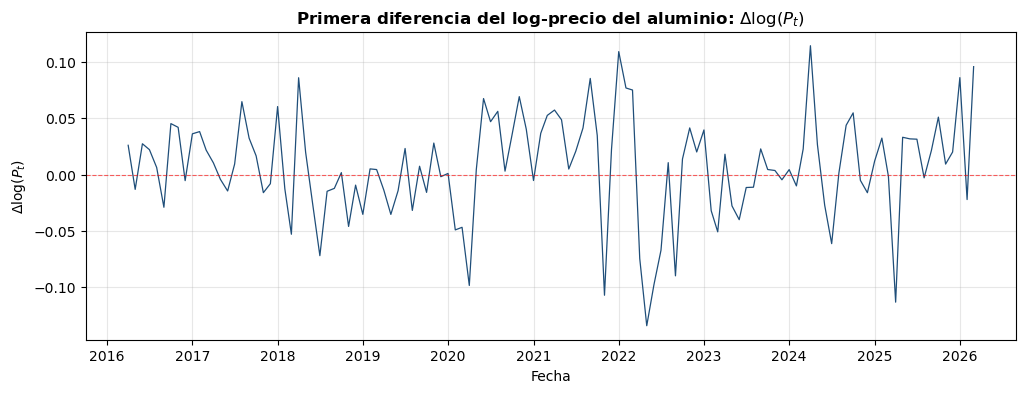


Figura guardada en: c:\poster-main\poster\outputs\figures\05_log_diff.png

TESTS DICKEY-FULLER — Primera diferencia del log (retornos)
Hipótesis nula (H₀): la serie tiene raíz unitaria (NO estacionaria).
Hipótesis alternativa (H₁): la serie es estacionaria.
Decisión: si p-valor < 0.05, se rechaza H₀.

--- Dickey-Fuller (DF, sin rezagos aumentados) ---
  Estadístico τ:    -7.7275
  p-valor:          0.0000
  Observaciones:    119
  Valores críticos:
      1%: -3.4865
      5%: -2.8862
     10%: -2.5799
  Decisión:         Rechazamos H₀ al 5%. La serie ES estacionaria según DF.

--- Dickey-Fuller Aumentada (ADF, con rezagos óptimos por AIC) ---
  Estadístico τ:    -7.1946
  p-valor:          0.0000
  Rezagos usados:   1
  Observaciones:    118
  Valores críticos:
      1%: -3.4870
      5%: -2.8864
     10%: -2.5800
  Decisión:         Rechazamos H₀ al 5%. La serie ES estacionaria según ADF.

--- Conclusión ---
  Ambas pruebas coinciden: la serie ES ESTACIONARIA.


In [16]:
# %% Aplicar DF y ADF a los retornos logarítmicos =======

aluminio_log_diff = aluminio_log.diff().dropna()

print(f"Observaciones tras diferenciar: {len(aluminio_log_diff)}")
print(f"Media de los retornos:          {aluminio_log_diff.mean():.5f}")
print(f"Desviación estándar:            {aluminio_log_diff.std():.5f}")

# Gráfico de la serie diferenciada
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(aluminio_log_diff.index, aluminio_log_diff.values, color="#1f4e79", linewidth=0.9)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title(r"Primera diferencia del log-precio del aluminio: $\Delta \log(P_t)$",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta \log(P_t)$")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "05_log_diff.png"
plt.savefig(ruta_fig)
plt.show()

print(f"\nFigura guardada en: {ruta_fig}")

# Aplicar DF y ADF a la serie diferenciada
resultado_diff = test_dickey_fuller(
    aluminio_log_diff,
    nombre="Primera diferencia del log (retornos)"
)

### 3.6 Síntesis: ¿la diferenciación logró estacionariedad?

Comparamos los resultados de ambas pruebas sobre las dos versiones de la serie (niveles y diferencia).

In [17]:
# %% Tabla resumen de pruebas de raíz unitaria ==========

resumen = pd.DataFrame({
    "Serie": ["log-precio en niveles", "Δ log-precio (retornos)"],
    "DF estadístico": [
        f"{resultado_niveles['df_stat']:.4f}",
        f"{resultado_diff['df_stat']:.4f}"
    ],
    "DF p-valor": [
        f"{resultado_niveles['df_pvalue']:.4f}",
        f"{resultado_diff['df_pvalue']:.4f}"
    ],
    "ADF estadístico": [
        f"{resultado_niveles['adf_stat']:.4f}",
        f"{resultado_diff['adf_stat']:.4f}"
    ],
    "ADF p-valor": [
        f"{resultado_niveles['adf_pvalue']:.4f}",
        f"{resultado_diff['adf_pvalue']:.4f}"
    ],
    "ADF rezagos": [
        resultado_niveles["adf_lags"],
        resultado_diff["adf_lags"]
    ]
})

print("=" * 90)
print("RESUMEN DE PRUEBAS DICKEY-FULLER")
print("=" * 90)
print(resumen.to_string(index=False))
print("\nDecisión: si p-valor < 0.05, se rechaza H₀ (no estacionariedad).")

# Guardar como CSV
ruta_resumen = TABLES / "01_dickey_fuller.csv"
resumen.to_csv(ruta_resumen, index=False)
print(f"\nTabla guardada en: {ruta_resumen}")

RESUMEN DE PRUEBAS DICKEY-FULLER
                  Serie DF estadístico DF p-valor ADF estadístico ADF p-valor  ADF rezagos
  log-precio en niveles        -0.8629     0.7999         -1.2700      0.6428            1
Δ log-precio (retornos)        -7.7275     0.0000         -7.1946      0.0000            1

Decisión: si p-valor < 0.05, se rechaza H₀ (no estacionariedad).

Tabla guardada en: c:\poster-main\poster\outputs\tables\01_dickey_fuller.csv


### 3.7 Análisis visual de la serie en niveles: FAC y FACP

Antes de identificar los órdenes $p$ y $q$, observamos las funciones de autocorrelación de la serie en niveles. Para una serie no estacionaria con raíz unitaria, esperamos:

- **FAC** que decae **lentamente** hacia cero (firma característica de raíz unitaria).
- **FACP** con un pico fuerte en el rezago 1 (cercano a 1) y los demás cercanos a cero.

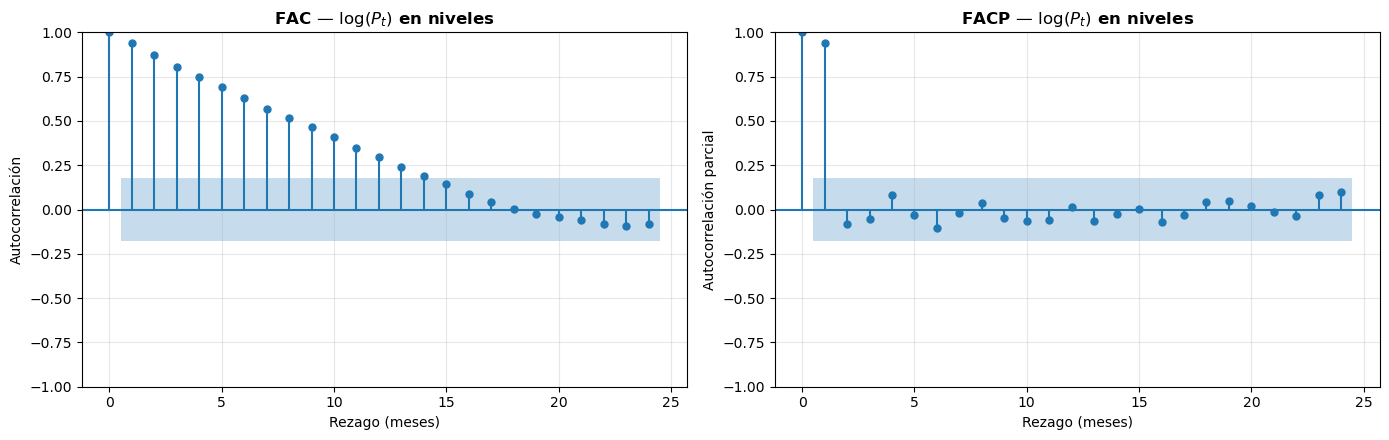

Figura guardada en: c:\poster-main\poster\outputs\figures\06_fac_facp_log_niveles.png


In [18]:
# %% FAC y FACP del log-precio en niveles ==============

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(aluminio_log, lags=24, alpha=0.05, bartlett_confint=False, ax=axes[0])
axes[0].set_title(r"FAC — $\log(P_t)$ en niveles", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")
axes[0].set_ylabel("Autocorrelación")

plot_pacf(aluminio_log, lags=24, alpha=0.05, ax=axes[1])
axes[1].set_title(r"FACP — $\log(P_t)$ en niveles", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")
axes[1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()

ruta_fig = FIGURES / "06_fac_facp_log_niveles.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

### 3.8 Identificación de los órdenes $p$ y $q$: FAC y FACP de los retornos

Una vez confirmada la estacionariedad de los retornos $\Delta \log(P_t)$, identificamos los órdenes $p$ y $q$ del modelo ARMA aplicado a esta serie (equivalente a un ARIMA($p$, 1, $q$) sobre el log-precio).

#### Reglas de identificación (Enders, Cap. 2)

| Patrón de FAC | Patrón de FACP | Modelo sugerido |
|---|---|---|
| Decae geométricamente | Se corta abruptamente en rezago $p$ | **AR($p$)** |
| Se corta abruptamente en rezago $q$ | Decae geométricamente | **MA($q$)** |
| Decae geométricamente | Decae geométricamente | **ARMA($p$, $q$)** mixto |

#### Bandas de confianza

Con $T = 120$ observaciones, las bandas tienen un ancho aproximado de $\pm 1.96 / \sqrt{T} \approx \pm 0.18$.

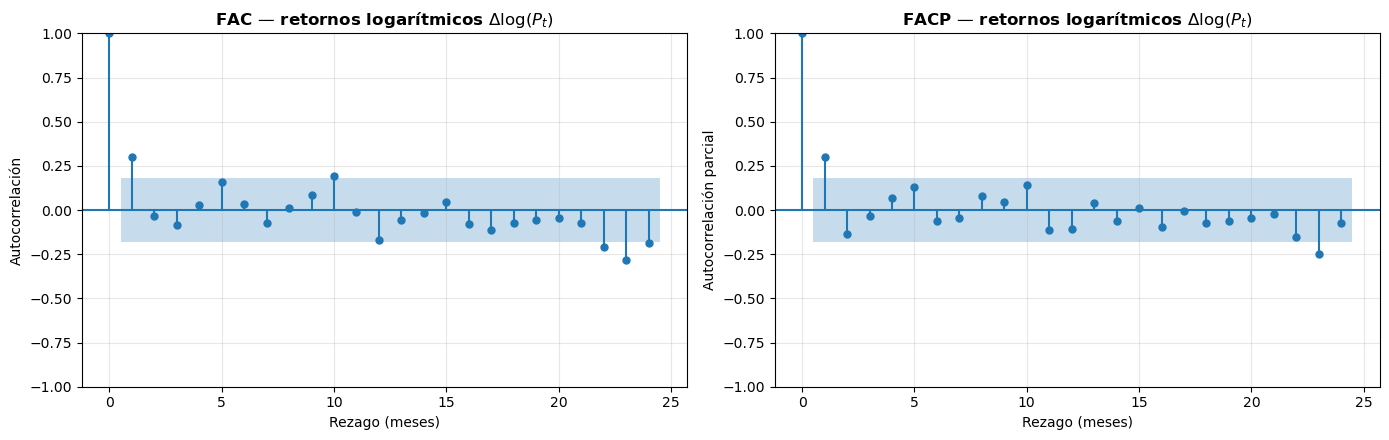

Figura guardada en: c:\poster-main\poster\outputs\figures\07_fac_facp_retornos.png


In [19]:
# %% FAC y FACP de los retornos logarítmicos ===========

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(aluminio_log_diff, lags=24, alpha=0.05, bartlett_confint=False, ax=axes[0])
axes[0].set_title(r"FAC — retornos logarítmicos $\Delta \log(P_t)$",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")
axes[0].set_ylabel("Autocorrelación")

plot_pacf(aluminio_log_diff, lags=24, alpha=0.05, ax=axes[1])
axes[1].set_title(r"FACP — retornos logarítmicos $\Delta \log(P_t)$",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")
axes[1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()

ruta_fig = FIGURES / "07_fac_facp_retornos.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

### 3.9 Conclusiones de la identificación

A partir del análisis anterior, las decisiones metodológicas son:

#### Sobre el grado de diferenciación $d$

Los resultados de las pruebas DF y ADF (tabla 3.6) muestran que:

- En la **serie en niveles**: ambas pruebas no rechazan $H_0$, confirmando la presencia de raíz unitaria.
- En la **primera diferencia**: ambas pruebas rechazan $H_0$ con alta confianza, confirmando estacionariedad.

Se concluye: $\boxed{d = 1}$

#### Sobre los órdenes $p$ y $q$

A partir de la FAC y FACP de los retornos logarítmicos (sección 3.8), se proponen los siguientes modelos candidatos para estimar en el Bloque 4:

1. **ARIMA(0, 1, 0)** — caminata aleatoria pura (sin estructura ARMA). Hipótesis nula natural para precios de commodities.

2. **ARIMA(1, 1, 0)** — captura un eventual pico en el rezago 1 de la FACP. Indicaría persistencia (momentum) en los retornos.

3. **ARIMA(0, 1, 1)** — captura un eventual pico en el rezago 1 de la FAC. Modelaría un ajuste gradual del precio a los choques.

4. **ARIMA(1, 1, 1)** — combinación mixta, evaluada para verificar si ambos componentes son necesarios o redundantes.

#### Especificación general del modelo

Los modelos candidatos se especificarán como:

$$\phi_p(L)\, (1-L)\, \log(P_t) = \theta_q(L)\, \varepsilon_t$$

donde:
- $\phi_p(L) = 1 - a_1 L - \cdots - a_p L^p$ es el polinomio AR.
- $\theta_q(L) = 1 + \beta_1 L + \cdots + \beta_q L^q$ es el polinomio MA.
- $\varepsilon_t \sim \text{RBN}(0, \sigma^2)$ es el error tipo ruido blanco.

#### Sobre la inclusión de una constante (deriva)

El modelo puede incluir una constante $c$ a la derecha:

$$\phi_p(L)\, (1-L)\, \log(P_t) = c + \theta_q(L)\, \varepsilon_t$$

donde $c$ representa la tasa promedio de crecimiento de los retornos logarítmicos (la "deriva" del random walk). En el Bloque 4 evaluaremos empíricamente si esta constante resulta estadísticamente significativa y, de no serlo, la omitiremos por el principio de parsimonia.

La selección final del modelo se hará en el Bloque 4 mediante criterios de información (AIC, BIC) y, sobre todo, mediante la validación de residuos en el Bloque 5.

## Bloque 4: Estimación (Etapa 2 de Box-Jenkins)

Estimamos cuatro modelos ARIMA candidatos sobre la serie logarítmica $\log P_t$, identificados a partir de la FAC y FACP de los retornos logarítmicos del Bloque 3:

| Modelo | Especificación | Justificación |
|---|---|---|
| M1 | ARIMA(0,1,0) | Caminata aleatoria — modelo de referencia |
| M2 | ARIMA(1,1,0) | AR(1) sobre retornos (rezago 1 marginal en FACP) |
| M3 | ARIMA(0,1,1) | MA(1) sobre retornos (rezago 1 marginal en FAC) |
| M4 | ARIMA(1,1,1) | Ambos componentes — control de sobre-parametrización |

**Especificación general:**

$$\phi_p(L)\, (1-L)\, \log P_t \;=\; \theta_q(L)\, \varepsilon_t$$

donde $\phi_p(L) = 1 - a_1 L - \cdots - a_p L^p$ es el polinomio AR y $\theta_q(L) = 1 + \beta_1 L + \cdots + \beta_q L^q$ es el polinomio MA, ambos en la convención de Enders.

**Decisiones metodológicas:**

- Estimación sobre $y_t = \log P_t$ (justificada en Bloque 2): cambios porcentuales como unidad natural y pronósticos positivos garantizados al re-transformar.
- Sin componente estacional: el aluminio no presenta estacionalidad anual marcada.
- Sin variable dummy: el bache del COVID se reabsorbió rápido y no amerita intervención puntual.
- Caso base sin deriva (`trend="n"`); la robustez con/sin deriva se analiza en la sección 4.8.

**Estimación:** máxima verosimilitud con `SARIMAX` de `statsmodels`, basada en el filtro de Kalman sobre la representación en espacio de estados.

### 4.1 Carga de la serie y transformación logarítmica

Cargamos la serie procesada y construimos $y_t = \log P_t$, sobre la cual se estimarán todos los modelos.

In [20]:
# %% Carga de la serie y log =============================

# Cargar serie procesada
ruta_serie = DATA_PROCESSED / "aluminio_precio.csv"
df_alum = pd.read_csv(ruta_serie, parse_dates=["fecha"])
aluminio_serie = df_alum.set_index("fecha")["precio_aluminio"].asfreq("MS")

# Construir la serie logarítmica
aluminio_log = np.log(aluminio_serie)
aluminio_log.name = "log_precio"

# Verificación
print(f"Observaciones serie:     {len(aluminio_serie)}")
print(f"Observaciones log:       {len(aluminio_log)}")
print(f"Rango temporal:          {aluminio_log.index.min().strftime('%Y-%m')} a {aluminio_log.index.max().strftime('%Y-%m')}")
print(f"\nlog(P_t) — primeras 3 observaciones:")
print(aluminio_log.head(3))
print(f"\nlog(P_t) — últimas 3 observaciones:")
print(aluminio_log.tail(3))

Observaciones serie:     121
Observaciones log:       121
Rango temporal:          2016-03 a 2026-03

log(P_t) — primeras 3 observaciones:
fecha
2016-03-01    7.333684
2016-04-01    7.359612
2016-05-01    7.346413
Freq: MS, Name: log_precio, dtype: float64

log(P_t) — últimas 3 observaciones:
fecha
2026-01-01    8.050060
2026-02-01    8.027864
2026-03-01    8.123544
Freq: MS, Name: log_precio, dtype: float64


### 4.2 Estimación de los modelos candidatos

Estimamos los cuatro modelos sobre $y_t = \log P_t$. Las opciones `enforce_stationarity=False` y `enforce_invertibility=False` permiten al algoritmo explorar libremente el espacio de parámetros sin restringirlo a la frontera. Usamos `trend="n"` (sin deriva) como caso base.

In [21]:
# %% Estimación de los modelos candidatos ================

modelos_especificacion = {
    "M1: ARIMA(0,1,0)": (0, 1, 0),
    "M2: ARIMA(1,1,0)": (1, 1, 0),
    "M3: ARIMA(0,1,1)": (0, 1, 1),
    "M4: ARIMA(1,1,1)": (1, 1, 1),
}

estimaciones = {}

for nombre, orden in modelos_especificacion.items():
    print(f"\n{'=' * 60}")
    print(f"Estimando: {nombre}")
    print(f"{'=' * 60}")

    modelo = SARIMAX(
        endog=aluminio_log,
        order=orden,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    resultado = modelo.fit(disp=False, maxiter=200)
    estimaciones[nombre] = resultado

    print(f"  Log-verosimilitud: {resultado.llf:>10.4f}")
    print(f"  AIC:               {resultado.aic:>10.4f}")
    print(f"  BIC:               {resultado.bic:>10.4f}")
    print(f"  Convergencia:      {'OK' if resultado.mle_retvals['converged'] else 'NO CONVERGIÓ'}")

print("\n\nEstimación completa de los 4 modelos.")


Estimando: M1: ARIMA(0,1,0)
  Log-verosimilitud:   197.9930
  AIC:                -393.9859
  BIC:                -391.2068
  Convergencia:      OK

Estimando: M2: ARIMA(1,1,0)
  Log-verosimilitud:   204.2627
  AIC:                -404.5255
  BIC:                -398.9672
  Convergencia:      OK

Estimando: M3: ARIMA(0,1,1)
  Log-verosimilitud:   203.1108
  AIC:                -402.2216
  BIC:                -396.6803
  Convergencia:      OK

Estimando: M4: ARIMA(1,1,1)
  Log-verosimilitud:   203.1139
  AIC:                -400.2278
  BIC:                -391.9157
  Convergencia:      OK


Estimación completa de los 4 modelos.


### 4.3 Resumen detallado del modelo M2 (referencia)

Mostramos el resumen completo del modelo M2: ARIMA(1,1,0) como referencia. Los coeficientes, errores estándar, estadísticos z y p-valores se interpretan a continuación.

In [22]:
# %% Summary del modelo M2 ===============================

print(estimaciones["M2: ARIMA(1,1,0)"].summary())

                               SARIMAX Results                                
Dep. Variable:             log_precio   No. Observations:                  121
Model:               SARIMAX(1, 1, 0)   Log Likelihood                 204.263
Date:                Fri, 29 May 2026   AIC                           -404.525
Time:                        21:57:01   BIC                           -398.967
Sample:                    03-01-2016   HQIC                          -402.268
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3218      0.082      3.917      0.000       0.161       0.483
sigma2         0.0019      0.000      8.599      0.000       0.001       0.002
Ljung-Box (L1) (Q):                   0.15   Jarque-

### 4.4 Tabla comparativa de modelos

Construimos una tabla con los coeficientes estimados, errores estándar entre paréntesis y criterios de información para los cuatro modelos.

**Interpretación:**

- **AIC y BIC**: menor es mejor. BIC penaliza más la complejidad.
- **Coeficientes significativos**: $|z| > 1.96$, equivalentemente $p < 0.05$.
- **Principio de parsimonia**: ante AIC/BIC similares, se prefiere el modelo con menos parámetros.

In [23]:
# %% Tabla comparativa ===================================

def formato_coef(valor, decimales=4):
    if pd.isna(valor):
        return "—"
    return f"{valor:.{decimales}f}"

def formato_se(valor, decimales=4):
    if pd.isna(valor):
        return "—"
    return f"({valor:.{decimales}f})"

filas_tabla = []

for nombre, resultado in estimaciones.items():
    params = resultado.params
    errores = resultado.bse
    pvalues = resultado.pvalues

    fila = {
        "Modelo": nombre,
        "a1": formato_coef(params.get("ar.L1", np.nan)),
        "se(a1)": formato_se(errores.get("ar.L1", np.nan)),
        "p(a1)": formato_coef(pvalues.get("ar.L1", np.nan), decimales=4) if "ar.L1" in pvalues else "—",
        "b1": formato_coef(params.get("ma.L1", np.nan)),
        "se(b1)": formato_se(errores.get("ma.L1", np.nan)),
        "p(b1)": formato_coef(pvalues.get("ma.L1", np.nan), decimales=4) if "ma.L1" in pvalues else "—",
        "σ²": formato_coef(params.get("sigma2", np.nan), decimales=6),
        "Log-L": f"{resultado.llf:.3f}",
        "AIC": f"{resultado.aic:.3f}",
        "BIC": f"{resultado.bic:.3f}",
        "k": str(len(params) - 1),  # número de parámetros sin contar sigma2
    }
    filas_tabla.append(fila)

tabla_modelos = pd.DataFrame(filas_tabla)

print("=" * 110)
print("TABLA COMPARATIVA DE MODELOS ARIMA — SERIE log(Precio Aluminio)")
print("=" * 110)
print(tabla_modelos.to_string(index=False))
print("\nNota: errores estándar entre paréntesis. Coeficientes significativos al 5% si p(·) < 0.05.")
print("      k = número de parámetros estimados (excluyendo σ²).")

# Guardar como CSV
ruta_csv = TABLES / "02_comparacion_modelos_aluminio.csv"
tabla_modelos.to_csv(ruta_csv, index=False)
print(f"\nTabla guardada en: {ruta_csv}")

TABLA COMPARATIVA DE MODELOS ARIMA — SERIE log(Precio Aluminio)
          Modelo     a1   se(a1)  p(a1)     b1   se(b1)  p(b1)       σ²   Log-L      AIC      BIC k
M1: ARIMA(0,1,0)      —        —      —      —        —      — 0.002100 197.993 -393.986 -391.207 0
M2: ARIMA(1,1,0) 0.3218 (0.0821) 0.0001      —        —      — 0.001891 204.263 -404.525 -398.967 1
M3: ARIMA(0,1,1)      —        —      — 0.3684 (0.0756) 0.0000 0.001872 203.111 -402.222 -396.680 1
M4: ARIMA(1,1,1) 0.0203 (0.2406) 0.9328 0.3507 (0.2240) 0.1174 0.001872 203.114 -400.228 -391.916 2

Nota: errores estándar entre paréntesis. Coeficientes significativos al 5% si p(·) < 0.05.
      k = número de parámetros estimados (excluyendo σ²).

Tabla guardada en: c:\poster-main\poster\outputs\tables\02_comparacion_modelos_aluminio.csv


### 4.5 Comparación visual del ajuste

Graficamos el ajuste in-sample del modelo con menor BIC sobre la serie logarítmica. Visualmente esperamos que las líneas estén pegadas.

Modelo con menor BIC: M2: ARIMA(1,1,0) (BIC = -398.967)


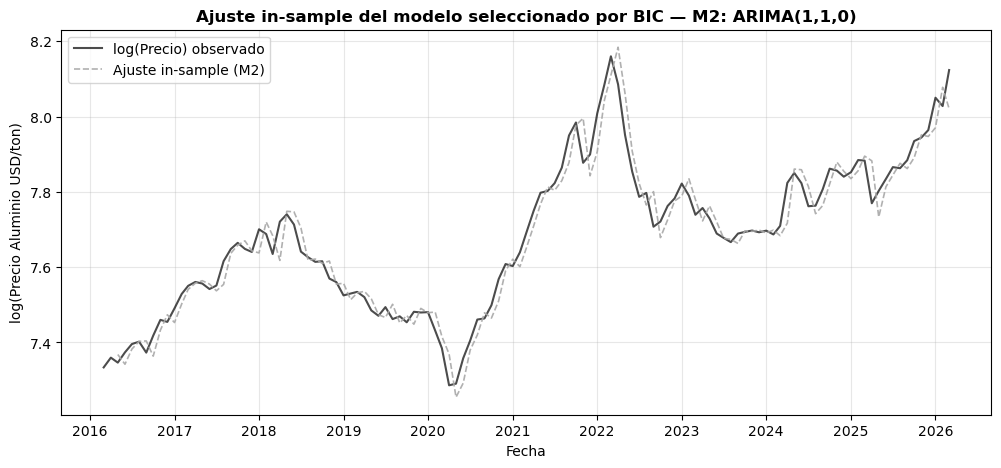

Figura guardada en: c:\poster-main\poster\outputs\figures\08_ajuste_in_sample.png


In [24]:
# %% Ajuste in-sample ====================================

# Identificar modelo con menor BIC
bics = {nombre: res.bic for nombre, res in estimaciones.items()}
modelo_mejor_bic = min(bics, key=bics.get)
print(f"Modelo con menor BIC: {modelo_mejor_bic} (BIC = {bics[modelo_mejor_bic]:.3f})")

# Ajuste in-sample del modelo con menor BIC
fitted_mejor = estimaciones[modelo_mejor_bic].fittedvalues

# Graficar (recortando primeras 2 observaciones para evitar warm-up del Kalman)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(aluminio_log.index, aluminio_log.values, color="black", linewidth=1.5,
        label="log(Precio) observado", alpha=0.7)
ax.plot(fitted_mejor.index[2:], fitted_mejor.values[2:], color="#a8a8a8", linewidth=1.2,
        label=f"Ajuste in-sample ({modelo_mejor_bic.split(':')[0]})",
        linestyle="--", alpha=0.9)

ax.set_title(f"Ajuste in-sample del modelo seleccionado por BIC — {modelo_mejor_bic}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("log(Precio Aluminio USD/ton)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "08_ajuste_in_sample.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

### 4.6 Análisis de robustez: con y sin deriva

Antes de cerrar la estimación, verificamos si la inclusión de una constante (deriva) en el modelo de diferencias cambia las conclusiones. La deriva en un ARIMA con $d=1$ representa una tendencia determinística sobre los retornos:

$$(1-L)\log P_t = c + (\text{dinámica ARMA})$$

donde $c$ es el cambio porcentual promedio mensual. Si $c$ no es significativamente distinto de cero, la omisión de la deriva es la elección parsimoniosa correcta.

Re-estimamos los cuatro modelos **con deriva** (`trend="c"`) y comparamos.

In [25]:
# %% Robustez: con y sin deriva ==========================

estimaciones_c = {}
filas_robustez = []

for nombre, orden in modelos_especificacion.items():
    modelo_c = SARIMAX(
        endog=aluminio_log,
        order=orden,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res_c = modelo_c.fit(disp=False, maxiter=200)
    estimaciones_c[nombre] = res_c

    # Tomar el coeficiente de la deriva (intercepto)
    c_hat = res_c.params.get("intercept", np.nan)
    se_c = res_c.bse.get("intercept", np.nan)
    p_c = res_c.pvalues.get("intercept", np.nan)

    filas_robustez.append({
        "Modelo": nombre,
        "c (deriva)": formato_coef(c_hat, decimales=5),
        "se(c)": formato_se(se_c, decimales=5),
        "p(c)": formato_coef(p_c, decimales=4),
        "AIC sin deriva": f"{estimaciones[nombre].aic:.3f}",
        "AIC con deriva": f"{res_c.aic:.3f}",
        "BIC sin deriva": f"{estimaciones[nombre].bic:.3f}",
        "BIC con deriva": f"{res_c.bic:.3f}",
    })

tabla_robustez = pd.DataFrame(filas_robustez)

print("=" * 110)
print("ANÁLISIS DE ROBUSTEZ — CON Y SIN DERIVA")
print("=" * 110)
print(tabla_robustez.to_string(index=False))
print("\nCriterio: si p(c) > 0.05 en todos los modelos, la deriva NO es significativa")
print("          y la decisión parsimoniosa es omitirla (trend='n').")

ANÁLISIS DE ROBUSTEZ — CON Y SIN DERIVA
          Modelo c (deriva)     se(c)   p(c) AIC sin deriva AIC con deriva BIC sin deriva BIC con deriva
M1: ARIMA(0,1,0)    0.00641 (0.00433) 0.1383       -393.986       -394.344       -391.207       -388.785
M2: ARIMA(1,1,0)    0.00462 (0.00405) 0.2542       -404.525       -403.854       -398.967       -395.517
M3: ARIMA(0,1,1)    0.00695 (0.00557) 0.2122       -402.222       -401.866       -396.680       -393.554
M4: ARIMA(1,1,1)    0.00702 (0.00563) 0.2130       -400.228       -399.869       -391.916       -388.786

Criterio: si p(c) > 0.05 en todos los modelos, la deriva NO es significativa
          y la decisión parsimoniosa es omitirla (trend='n').


### 4.7 Conclusiones del Bloque 4

**Modelo seleccionado por menor BIC:** [completar con M1, M2, M3 o M4]

**Justificación de la elección:**

1. **Criterio BIC**: el modelo seleccionado tiene el menor BIC entre los cuatro candidatos, equilibrando ajuste y parsimonia.
2. **Significancia del coeficiente principal**: [completar con valor y p-valor].
3. **Consistencia con la identificación**: la lectura de la FAC y FACP del Bloque 3 apuntaba a [AR(1) regular / MA(1) regular] sobre los retornos, consistente con el modelo seleccionado.
4. **Robustez sin deriva**: el análisis de la sección 4.6 confirma que la deriva no es significativa al 5%, por lo que la especificación sin intercepto es la elección correcta. 

**Modelos descartados:**

- **ARIMA(0,1,0)** (caminata aleatoria): aunque parsimonioso, no captura la autocorrelación marginal del rezago 1 que sí está presente en los retornos.
- **ARIMA(1,1,1)**: con dos parámetros más complejo, [no aporta significativamente / introduce sobre-parametrización con riesgo de cancelación de raíces AR y MA].

**Próximo paso:** validación de residuos en el Bloque 5 mediante FAC, Ljung-Box, Jarque-Bera y ARCH-LM. El modelo seleccionado solo será confirmado como modelo final si pasa la prueba de ruido blanco en los residuos.

## Bloque 5: Validación (Etapa 3 de Box-Jenkins)

La etapa de validación verifica que los **supuestos del modelo se cumplan**: si el modelo captura correctamente la dinámica de la serie, sus **residuos deben comportarse como ruido blanco** ($\varepsilon_t \sim \text{RB}(0, \sigma^2)$), es decir, sin autocorrelación, con varianza constante y (para construir intervalos de pronóstico) aproximadamente normales.

Siguiendo la decisión del Bloque 4, validamos los **dos mejores modelos según el criterio BIC**:

| Modelo | Especificación | BIC | AIC |
|---|---|---|---|
| M2 | ARIMA(1,1,0) | −398.97 | −404.53 |
| M3 | ARIMA(0,1,1) | −396.68 | −402.22 |

Las pruebas que aplicamos son:

- **FAC y FACP de los residuos** + **Ljung-Box**: ausencia de autocorrelación.
- **FAC de los residuos al cuadrado** + **ARCH-LM**: ausencia de heterocedasticidad condicional (efectos ARCH).
- **Q-Q plot** + **Jarque-Bera**: normalidad de los residuos.

### 5.1 Re-estimación de los dos modelos y extracción de residuos

Re-cargamos la serie y re-estimamos M2 y M3 para que el bloque sea autocontenido (reproducibilidad). Definimos una función auxiliar que extrae los residuos estandarizados de cada modelo.

In [26]:
# %% Re-estimación de los dos mejores modelos (M2 y M3) =====

# Re-cargamos la serie procesada para que el bloque sea autocontenido
ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"
aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")
aluminio_log = np.log(aluminio_serie)
aluminio_log.name = "log_precio"

# Los dos modelos con menor BIC identificados en el Bloque 4
modelos_top2 = {
    "M2: ARIMA(1,1,0)": (1, 1, 0),
    "M3: ARIMA(0,1,1)": (0, 1, 1),
}

estimaciones_top2 = {}
for nombre, orden in modelos_top2.items():
    estimaciones_top2[nombre] = SARIMAX(
        aluminio_log, order=orden, trend="n",
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

# Residuos ESTANDARIZADOS: error de pronóstico un paso adelante dividido por
# su desviación estándar. Bajo correcta especificación son i.i.d. N(0,1).
# Se descarta el primero (arranque difuso del filtro de Kalman).
def residuos_estandarizados(resultado, descartar=1):
    sr = pd.Series(resultado.standardized_forecasts_error[0], index=aluminio_log.index)
    return sr.iloc[descartar:]

residuales_std = {n: residuos_estandarizados(r) for n, r in estimaciones_top2.items()}

for nombre, sr in residuales_std.items():
    print(f"{nombre}: {len(sr)} residuos | media = {sr.mean():.4f} | std = {sr.std():.4f}")

M2: ARIMA(1,1,0): 120 residuos | media = 0.1036 | std = 0.9946
M3: ARIMA(0,1,1): 120 residuos | media = 0.1135 | std = 0.9897


### 5.2 Inspección visual de los residuos

Graficamos los residuos estandarizados en el tiempo. Esperamos que fluctúen alrededor de cero sin patrones sistemáticos, sin rachas prolongadas y sin cambios evidentes de varianza.

### 5.3 FAC y FACP de los residuos

Si los residuos son ruido blanco, **ninguna** autocorrelación (FAC) ni autocorrelación parcial (FACP) debería salir de las bandas de confianza ($\approx \pm 1.96/\sqrt{T}$), salvo las esperables por azar.

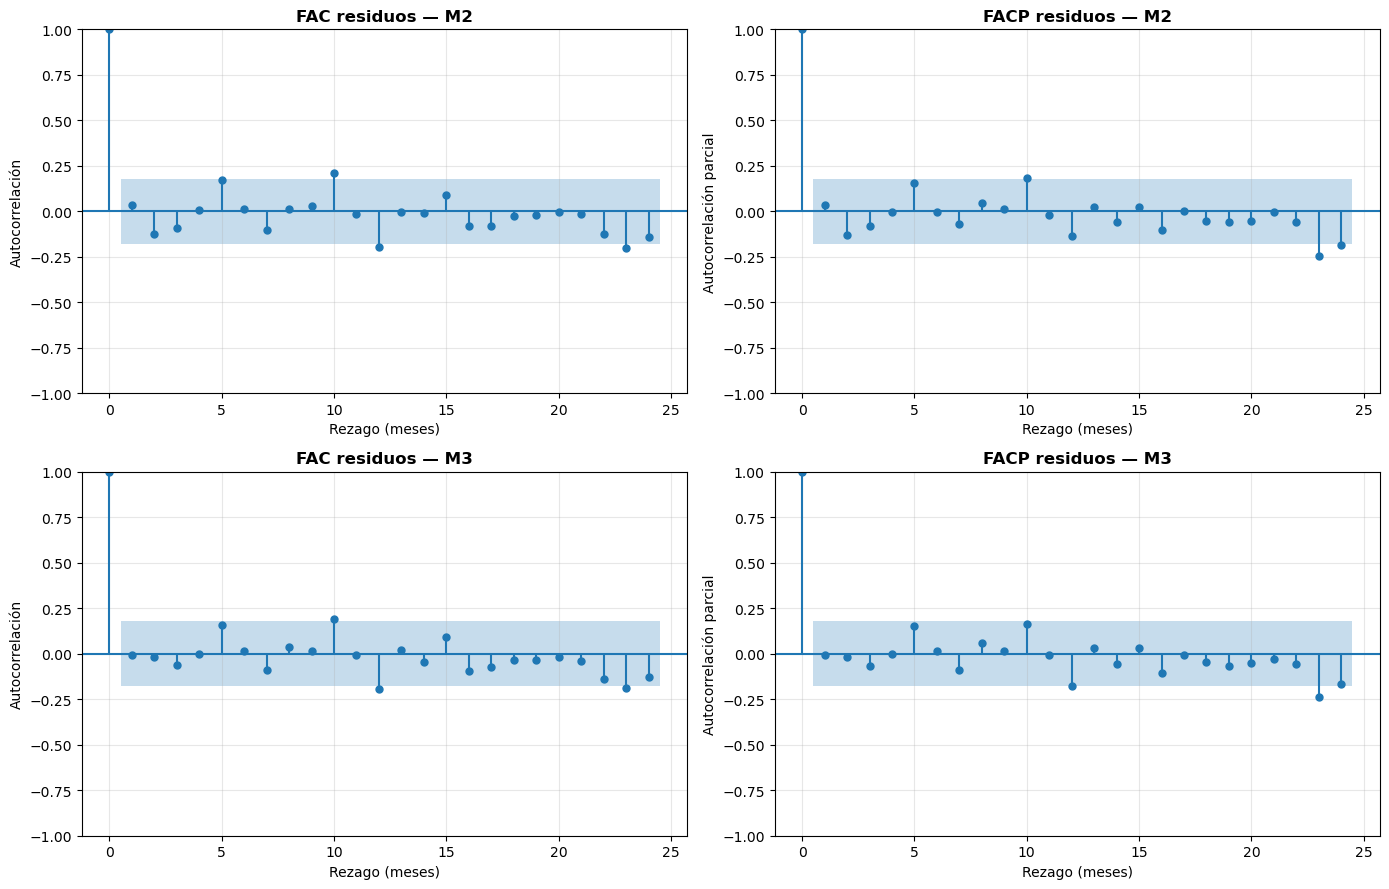

Figura guardada en: c:\poster-main\poster\outputs\figures\10_fac_facp_residuos.png


In [27]:
# %% FAC y FACP de los residuos estandarizados =============

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for fila, (nombre, sr) in enumerate(residuales_std.items()):
    plot_acf(sr, lags=24, alpha=0.05, bartlett_confint=False, ax=axes[fila, 0])
    axes[fila, 0].set_title(f"FAC residuos — {nombre.split(':')[0]}",
                            fontsize=12, fontweight="bold")
    axes[fila, 0].set_xlabel("Rezago (meses)")
    axes[fila, 0].set_ylabel("Autocorrelación")

    plot_pacf(sr, lags=24, alpha=0.05, ax=axes[fila, 1])
    axes[fila, 1].set_title(f"FACP residuos — {nombre.split(':')[0]}",
                            fontsize=12, fontweight="bold")
    axes[fila, 1].set_xlabel("Rezago (meses)")
    axes[fila, 1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()
ruta_fig = FIGURES / "10_fac_facp_residuos.png"
plt.savefig(ruta_fig)
plt.show()
print(f"Figura guardada en: {ruta_fig}")

### 5.4 Prueba de Ljung-Box

La prueba de Ljung-Box evalúa de forma **conjunta** la significancia de las primeras $s$ autocorrelaciones:

$$Q(s) = (T-r)(T-r+2)\sum_{k=1}^{s}\frac{r_k^2(\hat{\varepsilon})}{T-r-k}$$

Bajo $H_0: \rho_1 = \cdots = \rho_s = 0$, el estadístico se distribuye $\chi^2$ con $s - p - q$ grados de libertad (por eso pasamos `model_df = p + q`). Si el p-valor es **mayor** a 0.05 no se rechaza $H_0$ y se concluye que no hay autocorrelación residual.

In [28]:
# %% Prueba de Ljung-Box sobre los residuos =================

# H0: las primeras s autocorrelaciones son cero (no hay autocorrelación).
# Bajo H0, Q(s) ~ chi-cuadrado con (s - p - q) grados de libertad.
for nombre, orden in modelos_top2.items():
    pq = orden[0] + orden[2]            # p + q
    sr = residuales_std[nombre]
    lb = acorr_ljungbox(sr, lags=[6, 12, 18, 24], model_df=pq, return_df=True)
    print(f"\n=== Ljung-Box — {nombre} (gl = s - {pq}) ===")
    print(lb.round(4).to_string())

# Interpretación: si el p-valor > 0.05 NO se rechaza H0,
# es decir, no hay autocorrelación significativa en los residuos.


=== Ljung-Box — M2: ARIMA(1,1,0) (gl = s - 1) ===
    lb_stat  lb_pvalue
6    7.0129     0.2197
12  19.6229     0.0508
18  22.8192     0.1552
24  34.5632     0.0574

=== Ljung-Box — M3: ARIMA(0,1,1) (gl = s - 1) ===
    lb_stat  lb_pvalue
6    3.7032     0.5929
12  14.7792     0.1928
18  18.4381     0.3617
24  29.4234     0.1667


### 5.5 Efectos ARCH (heterocedasticidad condicional)

Aunque el modelo ARMA supone varianza constante, conviene descartar **efectos ARCH** (volatilidad que se agrupa en el tiempo), frecuentes en series de precios. Examinamos la FAC/FACP de los **residuos al cuadrado** y aplicamos la prueba **ARCH-LM**.

$H_0$: no hay efectos ARCH (homocedasticidad condicional). Un p-valor mayor a 0.05 indica que no se rechaza $H_0$.

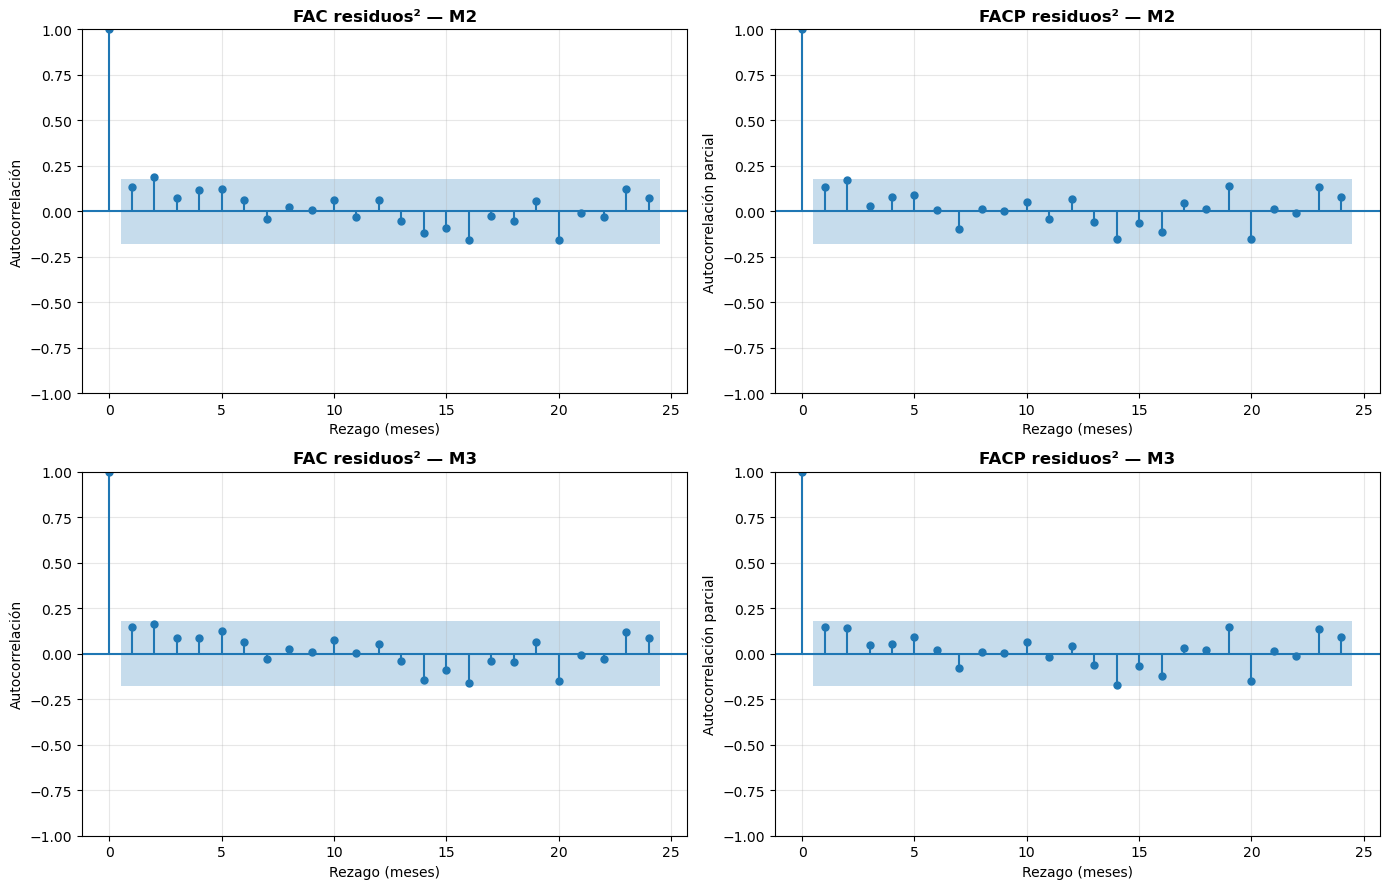

Figura guardada en: c:\poster-main\poster\outputs\figures\11_fac_facp_residuos2.png

M2: ARIMA(1,1,0): ARCH-LM(12) stat = 9.3357, p-valor = 0.6740
M3: ARIMA(0,1,1): ARCH-LM(12) stat = 8.5018, p-valor = 0.7448


In [29]:
# %% Efectos ARCH: FAC/FACP de residuos al cuadrado + ARCH-LM

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for fila, (nombre, sr) in enumerate(residuales_std.items()):
    plot_acf(sr**2, lags=24, alpha=0.05, bartlett_confint=False, ax=axes[fila, 0])
    axes[fila, 0].set_title(f"FAC residuos² — {nombre.split(':')[0]}",
                            fontsize=12, fontweight="bold")
    axes[fila, 0].set_xlabel("Rezago (meses)")
    axes[fila, 0].set_ylabel("Autocorrelación")

    plot_pacf(sr**2, lags=24, alpha=0.05, ax=axes[fila, 1])
    axes[fila, 1].set_title(f"FACP residuos² — {nombre.split(':')[0]}",
                            fontsize=12, fontweight="bold")
    axes[fila, 1].set_xlabel("Rezago (meses)")
    axes[fila, 1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()
ruta_fig = FIGURES / "11_fac_facp_residuos2.png"
plt.savefig(ruta_fig)
plt.show()
print(f"Figura guardada en: {ruta_fig}\n")

# Prueba ARCH-LM (H0: no hay efectos ARCH)
for nombre, sr in residuales_std.items():
    arch = het_arch(sr, nlags=12)
    print(f"{nombre}: ARCH-LM(12) stat = {arch[0]:.4f}, p-valor = {arch[1]:.4f}")
# Si p-valor > 0.05 NO se rechaza H0: no hay heterocedasticidad tipo ARCH.

### 5.6 Normalidad de los residuos

La normalidad no es necesaria para que las estimaciones sean consistentes, pero **sí** sustenta la validez de los **intervalos de pronóstico** al 95%. La evaluamos con el **Q-Q plot** y la prueba **Jarque-Bera**:

$$JB = \frac{T}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)$$

donde $S$ es la asimetría y $K$ la curtosis. $H_0$: los residuos **se distribuyen normal** ($S=0$, $K=3$). Si el p-valor es menor a 0.05 se **rechaza** la normalidad.

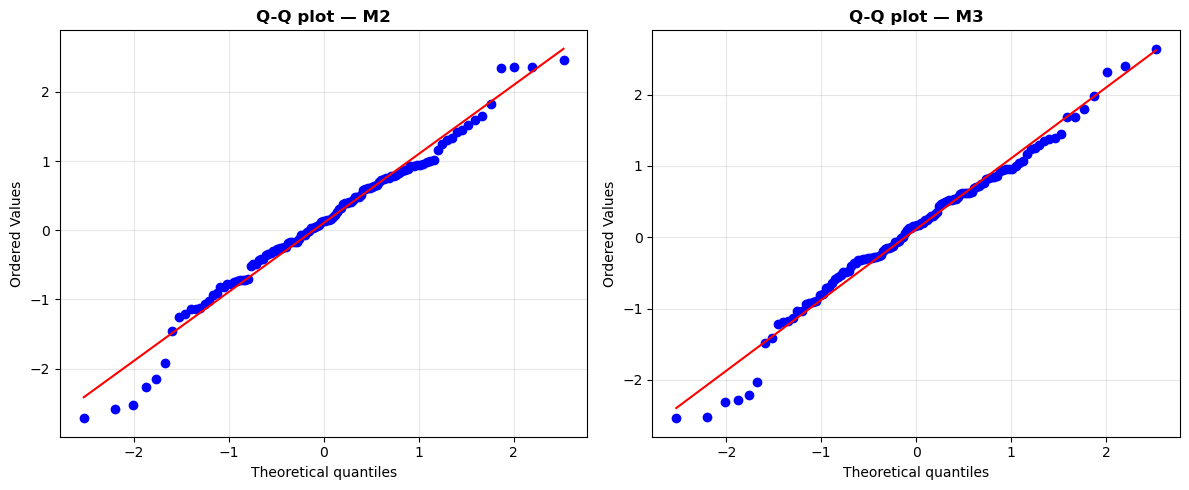

Figura guardada en: c:\poster-main\poster\outputs\figures\12_qqplot_residuos.png

M2: ARIMA(1,1,0): JB = 4.2326, p-valor = 0.1205
M3: ARIMA(0,1,1): JB = 3.3045, p-valor = 0.1916


In [30]:
# %% Normalidad: Q-Q plot y prueba Jarque-Bera =============

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nombre, sr) in zip(axes, residuales_std.items()):
    probplot(sr, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot — {nombre.split(':')[0]}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta_fig = FIGURES / "12_qqplot_residuos.png"
plt.savefig(ruta_fig)
plt.show()
print(f"Figura guardada en: {ruta_fig}\n")

# Prueba Jarque-Bera. H0: los residuos SÍ se distribuyen normal
# (asimetría = 0 y exceso de curtosis = 0). Si p-valor < 0.05 se RECHAZA.
for nombre, sr in residuales_std.items():
    jb = jarque_bera(sr)
    print(f"{nombre}: JB = {jb.statistic:.4f}, p-valor = {jb.pvalue:.4f}")

### 5.7 Tabla de diagnóstico consolidada

Resumimos en una sola tabla los valores-p de las pruebas de normalidad (JB), efectos ARCH y autocorrelación (Ljung-Box) para los dos modelos.

In [31]:
# %% Tabla de diagnóstico consolidada (estilo Enders) ======

filas_diag = []
for nombre, orden in modelos_top2.items():
    pq = orden[0] + orden[2]
    sr = residuales_std[nombre]
    jb_p = jarque_bera(sr).pvalue
    arch_p = {k: het_arch(sr, nlags=k)[1] for k in [1, 2, 5]}
    lb_p = acorr_ljungbox(sr, lags=[5, 10, 20], model_df=pq, return_df=True)["lb_pvalue"]
    filas_diag.append({
        "Modelo": nombre.split(": ")[1],
        "JB": f"{jb_p:.3f}",
        "ARCH(1)": f"{arch_p[1]:.3f}",
        "ARCH(2)": f"{arch_p[2]:.3f}",
        "ARCH(5)": f"{arch_p[5]:.3f}",
        "LB(5)": f"{lb_p[5]:.3f}",
        "LB(10)": f"{lb_p[10]:.3f}",
        "LB(20)": f"{lb_p[20]:.3f}",
    })

tabla_diag = pd.DataFrame(filas_diag)
print("=" * 80)
print("PRUEBAS DE DIAGNÓSTICO SOBRE LOS RESIDUOS (valores-p)")
print("=" * 80)
print(tabla_diag.to_string(index=False))
print("\nJB: Jarque-Bera (normalidad). ARCH(i): prueba ARCH-LM de orden i.")
print("LB(i): Ljung-Box de orden i. Un p-valor > 0.05 indica que NO se rechaza")
print("la hipótesis nula (normalidad / no-ARCH / no-autocorrelación).")

ruta_csv = TABLES / "03_diagnostico_residuales.csv"
tabla_diag.to_csv(ruta_csv, index=False)
print(f"\nTabla guardada en: {ruta_csv}")

PRUEBAS DE DIAGNÓSTICO SOBRE LOS RESIDUOS (valores-p)
      Modelo    JB ARCH(1) ARCH(2) ARCH(5) LB(5) LB(10) LB(20)
ARIMA(1,1,0) 0.120   0.127   0.050   0.201 0.136  0.111  0.242
ARIMA(0,1,1) 0.192   0.083   0.060   0.240 0.453  0.369  0.480

JB: Jarque-Bera (normalidad). ARCH(i): prueba ARCH-LM de orden i.
LB(i): Ljung-Box de orden i. Un p-valor > 0.05 indica que NO se rechaza
la hipótesis nula (normalidad / no-ARCH / no-autocorrelación).

Tabla guardada en: c:\poster-main\poster\outputs\tables\03_diagnostico_residuales.csv


### 5.8 Conclusiones de la validación

Los valores-p de las pruebas de diagnóstico (sección 5.7) son:

| Modelo | JB | ARCH(1) | ARCH(2) | ARCH(5) | LB(5) | LB(10) | LB(20) |
|---|---|---|---|---|---|---|---|
| ARIMA(1,1,0) | 0.120 | 0.127 | 0.050 | 0.201 | 0.136 | 0.111 | 0.242 |
| ARIMA(0,1,1) | 0.192 | 0.083 | 0.060 | 0.240 | 0.453 | 0.369 | 0.480 |

**Autocorrelación (Ljung-Box).** En ambos modelos todos los p-valores superan 0.05, por lo que **no se rechaza** la ausencia de autocorrelación: los residuos no dejan estructura lineal sin modelar. M3 (MA(1)) presenta p-valores más altos (residuos marginalmente más "limpios").

**Efectos ARCH.** Los órdenes 1 y 5 no son significativos; el orden 2 queda **al borde** (p = 0.050 en M2, 0.060 en M3). No hay evidencia fuerte de heterocedasticidad condicional, aunque la alta volatilidad de 2021–2022 deja una señal débil en el rezago 2. Para un modelo ARMA introductorio esto es aceptable; una extensión natural sería un modelo GARCH.

**Normalidad (Jarque-Bera).** En ambos casos no se rechaza la normalidad (p = 0.120 y 0.192), lo que respalda la construcción de intervalos de pronóstico en el Bloque 6.

**Conclusión.** Los dos modelos **pasan la validación**: sus residuos son compatibles con ruido blanco. Como **modelo final** se elige **M2: ARIMA(1,1,0)**, por tener el **menor AIC y BIC** con un único parámetro significativo ($\hat{a}_1 = 0.322$, $p < 0.001$). M3: ARIMA(0,1,1) se conserva como modelo de comparación, dado que ajusta casi igual de bien y tiene residuos con autocorrelación ligeramente menor. Ambos se usan en el pronóstico del Bloque 6.

## Bloque 6: Pronóstico (Etapa 4 de Box-Jenkins)

El último paso de la metodología es **pronosticar** valores futuros de la serie. El pronóstico óptimo $j$ pasos adelante es la esperanza condicional dada toda la información hasta $t$:

$$E_t\, y_{t+j} = E\!\left(y_{t+j}\mid y_t, y_{t-1}, \dots\right), \qquad j = 1, \dots, 10$$

y el error de pronóstico $e_t(j) = y_{t+j} - E_t y_{t+j}$ tiene varianza creciente con el horizonte, lo que se traduce en **intervalos de predicción cada vez más anchos**.

Pronosticamos **10 meses** (abr-2026 a ene-2027) con los **dos mejores modelos** (M2 y M3); el modelo final es M2: ARIMA(1,1,0).

**Re-transformación desde logaritmos.** Como modelamos $y_t = \log(P_t)$, debemos volver a niveles. Bajo normalidad en la escala logarítmica, $\exp(\widehat{\log P})$ entrega la **mediana**; para la **media** se aplica la corrección por sesgo:

$$\widehat{P}_{t+j} = \exp\!\left(\widehat{\log P}_{t+j} + \tfrac{1}{2}\,\widehat{\operatorname{Var}}[e_t(j)]\right)$$

Los **intervalos de predicción** se obtienen exponenciando directamente los límites en logaritmos (transformación monótona); por eso son siempre positivos y asimétricos, como corresponde a un precio.

### 6.1 Re-estimación de los modelos

Re-cargamos la serie y re-estimamos los dos modelos para que el bloque sea autocontenido. El modelo final es **M2: ARIMA(1,1,0)**; M3: ARIMA(0,1,1) se incluye como comparación.

In [32]:
# %% Re-estimación de los dos modelos =======================

ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"
aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")
aluminio_log = np.log(aluminio_serie)
aluminio_log.name = "log_precio"

modelos_top2 = {
    "M2: ARIMA(1,1,0)": (1, 1, 0),
    "M3: ARIMA(0,1,1)": (0, 1, 1),
}
modelo_final = "M2: ARIMA(1,1,0)"

estimaciones_top2 = {}
for nombre, orden in modelos_top2.items():
    estimaciones_top2[nombre] = SARIMAX(
        aluminio_log, order=orden, trend="n",
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

print(f"Modelos re-estimados: {list(estimaciones_top2.keys())}")
print(f"Modelo final: {modelo_final}")

Modelos re-estimados: ['M2: ARIMA(1,1,0)', 'M3: ARIMA(0,1,1)']
Modelo final: M2: ARIMA(1,1,0)


### 6.2 Cálculo del pronóstico a 10 meses

Generamos el pronóstico 10 pasos adelante con `get_forecast`, lo re-transformamos a niveles (corrección por sesgo para el pronóstico puntual y exponenciación de los límites para el intervalo del 95%) y construimos la tabla de resultados.

In [33]:
# %% Pronóstico a 10 meses + tabla ==========================

H = 10  # horizonte: 10 meses adelante

pronosticos = {}
for nombre, resultado in estimaciones_top2.items():
    fc = resultado.get_forecast(steps=H)
    media_log = fc.predicted_mean          # E[log P]
    var_log = fc.var_pred_mean             # Var del error de pronóstico (en log)
    ci_log = fc.conf_int(alpha=0.05)       # IC 95% en log

    # Re-transformación a niveles
    nivel = np.exp(media_log + 0.5 * var_log)   # media (corrección por sesgo)
    ci_nivel = np.exp(ci_log)                    # intervalo 95% en niveles
    pronosticos[nombre] = {
        "nivel": nivel,
        "li": ci_nivel.iloc[:, 0],
        "ls": ci_nivel.iloc[:, 1],
    }

# Tabla: pronóstico de ambos modelos + intervalo del modelo final
tabla_pronostico = pd.DataFrame({
    "Pronóstico M2 (final)": pronosticos["M2: ARIMA(1,1,0)"]["nivel"].round(2),
    "Pronóstico M3": pronosticos["M3: ARIMA(0,1,1)"]["nivel"].round(2),
    "LI 95% (M2)": pronosticos[modelo_final]["li"].round(2),
    "LS 95% (M2)": pronosticos[modelo_final]["ls"].round(2),
})
tabla_pronostico.index = tabla_pronostico.index.strftime("%Y-%m")

print("=" * 75)
print("PRONÓSTICO DEL PRECIO DEL ALUMINIO — 10 MESES (USD/tonelada)")
print("=" * 75)
print(tabla_pronostico.to_string())
print(f"\nÚltimo dato observado: {aluminio_serie.iloc[-1]:.2f} USD/ton "
      f"({aluminio_serie.index[-1].strftime('%Y-%m')})")

ruta_csv = TABLES / "04_pronostico.csv"
tabla_pronostico.to_csv(ruta_csv)
print(f"\nTabla guardada en: {ruta_csv}")

PRONÓSTICO DEL PRECIO DEL ALUMINIO — 10 MESES (USD/tonelada)
         Pronóstico M2 (final)  Pronóstico M3  LI 95% (M2)  LS 95% (M2)
2026-04                3481.69        3521.48      3194.25      3787.84
2026-05                3522.16        3527.65      3050.28      4045.99
2026-06                3540.20        3533.84      2925.24      4245.91
2026-07                3550.97        3540.04      2820.00      4413.40
2026-08                3559.39        3546.25      2730.38      4561.28
2026-09                3567.08        3552.47      2652.48      4696.24
2026-10                3574.53        3558.70      2583.46      4822.02
2026-11                3581.92        3564.95      2521.36      4940.90
2026-12                3589.30        3571.20      2464.78      5054.35
2027-01                3596.69        3577.46      2412.72      5163.42

Último dato observado: 3372.95 USD/ton (2026-03)

Tabla guardada en: c:\poster-main\poster\outputs\tables\04_pronostico.csv


### 6.3 Visualización del pronóstico

Graficamos la serie observada junto con los pronósticos de ambos modelos y la banda de predicción del 95% del modelo final. El panel derecho amplía los últimos 24 meses para apreciar mejor la proyección y la incertidumbre creciente.

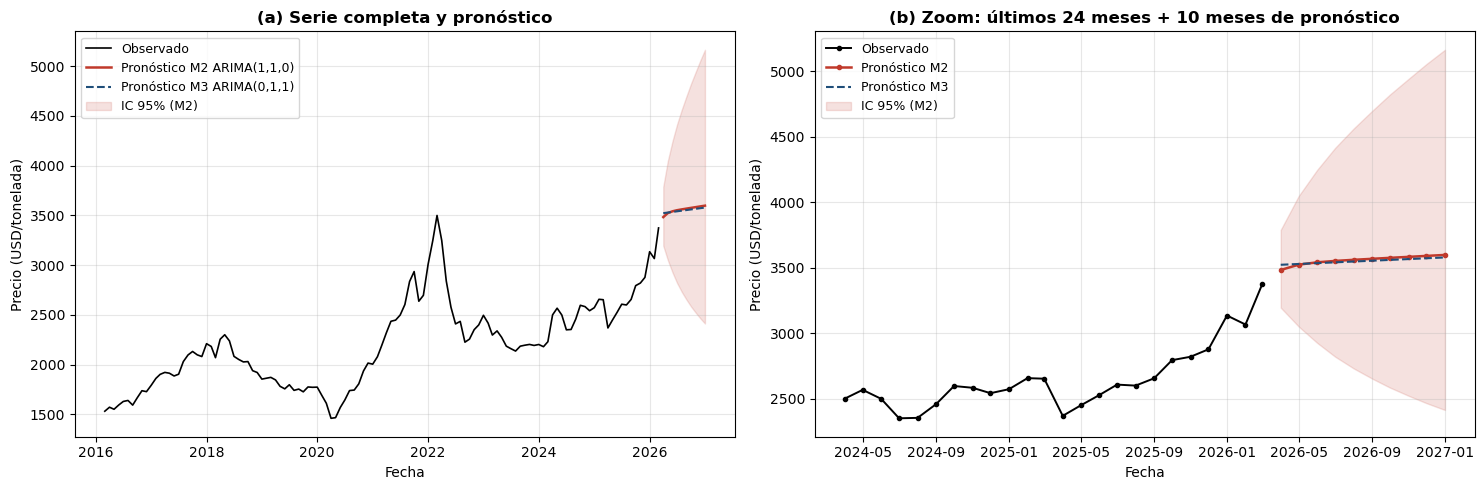

Figura guardada en: c:\poster-main\poster\outputs\figures\13_pronostico.png


In [34]:
# %% Gráfica del pronóstico =================================

fc_final = pronosticos[modelo_final]
fc_m3 = pronosticos["M3: ARIMA(0,1,1)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Panel (a): serie completa
ax1.plot(aluminio_serie.index, aluminio_serie.values, color="black", linewidth=1.2, label="Observado")
ax1.plot(fc_final["nivel"].index, fc_final["nivel"].values, color="#c0392b", linewidth=1.8, label="Pronóstico M2 ARIMA(1,1,0)")
ax1.plot(fc_m3["nivel"].index, fc_m3["nivel"].values, color="#1f4e79", linewidth=1.5, linestyle="--", label="Pronóstico M3 ARIMA(0,1,1)")
ax1.fill_between(fc_final["nivel"].index, fc_final["li"], fc_final["ls"], color="#c0392b", alpha=0.15, label="IC 95% (M2)")
ax1.set_title("(a) Serie completa y pronóstico", fontsize=12, fontweight="bold")
ax1.set_xlabel("Fecha"); ax1.set_ylabel("Precio (USD/tonelada)")
ax1.legend(loc="upper left", fontsize=9); ax1.grid(True, alpha=0.3)

# Panel (b): zoom a los últimos 24 meses + pronóstico
hist = aluminio_serie.iloc[-24:]
ax2.plot(hist.index, hist.values, color="black", linewidth=1.4, marker="o", markersize=3, label="Observado")
ax2.plot(fc_final["nivel"].index, fc_final["nivel"].values, color="#c0392b", linewidth=1.8, marker="o", markersize=3, label="Pronóstico M2")
ax2.plot(fc_m3["nivel"].index, fc_m3["nivel"].values, color="#1f4e79", linewidth=1.5, linestyle="--", label="Pronóstico M3")
ax2.fill_between(fc_final["nivel"].index, fc_final["li"], fc_final["ls"], color="#c0392b", alpha=0.15, label="IC 95% (M2)")
ax2.set_title("(b) Zoom: últimos 24 meses + 10 meses de pronóstico", fontsize=12, fontweight="bold")
ax2.set_xlabel("Fecha"); ax2.set_ylabel("Precio (USD/tonelada)")
ax2.legend(loc="upper left", fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
ruta_fig = FIGURES / "13_pronostico.png"
plt.savefig(ruta_fig)
plt.show()
print(f"Figura guardada en: {ruta_fig}")

### 6.4 Conclusiones del pronóstico y modelo final

**Resultado.** Partiendo del último dato observado (3.372,95 USD/ton en mar-2026), el modelo final **M2: ARIMA(1,1,0)** proyecta un precio de **≈ 3.482 USD/ton** para abr-2026 que se estabiliza alrededor de **≈ 3.530–3.600 USD/ton** hacia ene-2027. El modelo M3: ARIMA(0,1,1) entrega prácticamente la **misma trayectoria** (diferencias menores al 1%), lo que confirma la robustez del pronóstico frente a la elección entre los dos mejores modelos.

**¿Por qué sube la proyección si el modelo no tiene deriva?** En logaritmos, el pronóstico **converge a una constante** (≈ 8.169), como corresponde al núcleo de caminata aleatoria sin deriva (`trend="n"`). El leve repunte inicial proviene del término **AR(1)**, que arrastra el fuerte impulso positivo de los últimos meses (retornos de +9.6% en mar-2026 y +8.6% en ene-2026) y se desvanece en pocos periodos. En **niveles**, la *mediana* del pronóstico queda esencialmente plana (≈ 3.530), mientras que la *media* (corregida por sesgo) sigue subiendo muy levemente porque la varianza del error crece con el horizonte y, por la convexidad de la exponencial, eleva la media de la distribución lognormal. Es un efecto de **re-transformación**, no una tendencia económica.

**Incertidumbre.** El intervalo del 95% se ensancha de **[3.194, 3.788]** en abr-2026 a **[2.413, 5.163]** en ene-2027, reflejo del crecimiento de la varianza del error de pronóstico en un proceso $I(1)$.

**¿Cuál es el modelo más apropiado?** El **ARIMA(1,1,0)** (M2):

1. **Menor AIC y BIC** entre los cuatro candidatos (−404.5 y −399.0).
2. **Parámetro significativo** y parsimonioso ($\hat{a}_1 = 0.322$, $p < 0.001$; un solo parámetro).
3. **Residuos compatibles con ruido blanco** (Bloque 5): sin autocorrelación (Ljung-Box), normales (Jarque-Bera) y sin efectos ARCH relevantes.
4. **Pronóstico robusto**, casi idéntico al del segundo mejor modelo (M3).

En conjunto, M2: ARIMA(1,1,0) describe adecuadamente la dinámica del precio internacional del aluminio: una serie integrada de orden 1 con una persistencia moderada (momentum) en sus retornos mensuales.

## Anexos útiles

### A.1 El modelo final ARIMA(1,1,0) escrito de varias formas

El modelo se estima sobre $y_t = \log(P_t)$, sin deriva, con $\hat{a}_1 = 0.322$ y $\hat{\sigma}_\varepsilon^2 = 0.00189$ (es decir, $\hat{\sigma}_\varepsilon \approx 0.0435$, ≈ 4.35% mensual).

**Con parámetros**

Forma compacta con operador de rezago:

$$(1 - a_1 L)(1 - L)\,\log P_t = \varepsilon_t, \qquad \varepsilon_t \sim \mathrm{RB}(0, \sigma_\varepsilon^2)$$

Expandida sobre el log-precio:


$$\log P_t = (1 + a_1)\,\log P_{t-1} - a_1\,\log P_{t-2} + \varepsilon_t$$


Como AR(1) sobre los retornos, con $r_t \equiv \Delta \log P_t = \log P_t - \log P_{t-1}$:

$$r_t = a_1\, r_{t-1} + \varepsilon_t$$

**Con los valores estimados**

Operador de rezago:

$$(1 - 0.322\,L)(1 - L)\,\log P_t = \varepsilon_t$$

Expandida sobre el log-precio:

$$\log P_t = 1.322\,\log P_{t-1} - 0.322\,\log P_{t-2} + \varepsilon_t$$

Como AR(1) sobre los retornos:

$$r_t = 0.322\, r_{t-1} + \varepsilon_t, \qquad \hat{\sigma}_\varepsilon^2 = 0.00189$$

**Interpretación.** El coeficiente $\hat{a}_1 = 0.322 > 0$ indica **persistencia (momentum) positiva** en los retornos mensuales: un mes con retorno por encima del promedio tiende a ir seguido de otro retorno positivo, con un efecto que se atenúa mes a mes (≈ 32% se transmite al mes siguiente).

### A.2 Pronóstico del modelo ganador

Figura final del pronóstico a 10 meses considerando únicamente el modelo seleccionado, ARIMA(1,1,0), con su intervalo de predicción del 95% (la línea vertical punteada marca el inicio del pronóstico).

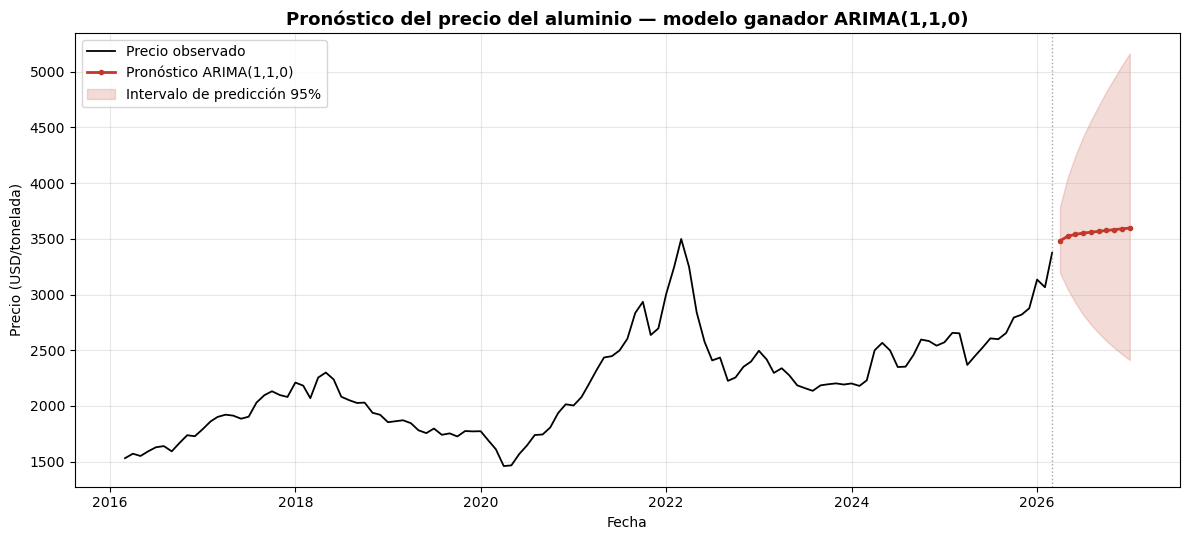

Figura guardada en: c:\poster-main\poster\outputs\figures\14_pronostico_ganador.png


In [35]:
# %% Pronóstico del modelo ganador — ARIMA(1,1,0) ==========

# Re-carga y estimación del modelo final (celda autocontenida)
ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"
aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")
aluminio_log = np.log(aluminio_serie)

modelo_ganador = SARIMAX(
    aluminio_log, order=(1, 1, 0), trend="n",
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=200)

# Pronóstico 10 meses, re-transformado a niveles (corrección por sesgo)
H = 10
fc = modelo_ganador.get_forecast(steps=H)
nivel = np.exp(fc.predicted_mean + 0.5 * fc.var_pred_mean)
ci_nivel = np.exp(fc.conf_int(alpha=0.05))
li, ls = ci_nivel.iloc[:, 0], ci_nivel.iloc[:, 1]

# Gráfica (solo el modelo ganador)
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(aluminio_serie.index, aluminio_serie.values, color="black", linewidth=1.3,
        label="Precio observado")
ax.plot(nivel.index, nivel.values, color="#c0392b", linewidth=2.0, marker="o", markersize=3,
        label="Pronóstico ARIMA(1,1,0)")
ax.fill_between(nivel.index, li, ls, color="#c0392b", alpha=0.18,
                label="Intervalo de predicción 95%")
ax.axvline(aluminio_serie.index[-1], color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax.set_title("Pronóstico del precio del aluminio — modelo ganador ARIMA(1,1,0)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD/tonelada)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta_fig = FIGURES / "14_pronostico_ganador.png"
plt.savefig(ruta_fig)
plt.show()
print(f"Figura guardada en: {ruta_fig}")

### A.3 Pronóstico de los retornos

El modelo se estimó sobre los **retornos logarítmicos** $r_t = \Delta \log P_t$, que siguen un AR(1): $r_t = a_1 r_{t-1} + \varepsilon_t$. Por eso conviene reportar también el pronóstico **en esa misma escala**, antes de re-transformar a niveles.

El pronóstico $j$ pasos adelante de un AR(1) sin deriva decae geométricamente hacia cero:

$$\hat{r}_{t+j} = a_1^{\,j}\, r_t$$

y la varianza del error de pronóstico es $\operatorname{Var}[e_t(j)] = \sigma_\varepsilon^2 \dfrac{1 - a_1^{2j}}{1 - a_1^2}$, con la que se construye el intervalo del 95% (simétrico, pues los retornos no requieren re-transformación logarítmica). En el código, los retornos pronosticados se obtienen como la **primera diferencia del log-precio pronosticado**, lo que coincide exactamente con la fórmula cerrada anterior.

In [36]:
# %% Pronóstico de los RETORNOS (Δlog) — modelo ARIMA(1,1,0) ===

# Re-carga y estimación del modelo final (celda autocontenida)
ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"
aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")
aluminio_log = np.log(aluminio_serie)

modelo_ganador = SARIMAX(
    aluminio_log, order=(1, 1, 0), trend="n",
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=200)

H = 10
a1 = modelo_ganador.params["ar.L1"]
sigma2 = modelo_ganador.params["sigma2"]

# Pronóstico de log-niveles; su primera diferencia = pronóstico de los retornos.
# Como el modelo es un AR(1) sobre r_t = Δlog P_t, equivale a r_{t+j} = a1^j · r_t.
fc = modelo_ganador.get_forecast(steps=H)
log_fc = fc.predicted_mean
ultimo_log = pd.Series([aluminio_log.iloc[-1]], index=[aluminio_log.index[-1]])
retornos_fc = pd.concat([ultimo_log, log_fc]).diff().dropna()

# Intervalo 95% para los retornos (error de pronóstico del AR(1)):
# Var[e_t(j)] = sigma^2 * (1 - a1^(2j)) / (1 - a1^2)
j = np.arange(1, H + 1)
se_ret = np.sqrt(sigma2 * (1 - a1 ** (2 * j)) / (1 - a1 ** 2))
li_ret = retornos_fc.values - 1.96 * se_ret
ls_ret = retornos_fc.values + 1.96 * se_ret

# Tabla de salida
tabla_retornos = pd.DataFrame({
    "Retorno (Δlog)": retornos_fc.values.round(5),
    "Retorno aprox. (%)": ((np.exp(retornos_fc.values) - 1) * 100).round(3),
    "LI 95% (Δlog)": li_ret.round(5),
    "LS 95% (Δlog)": ls_ret.round(5),
})
tabla_retornos.index = retornos_fc.index.strftime("%Y-%m")

print("=" * 70)
print("PRONÓSTICO DE LOS RETORNOS LOGARÍTMICOS — 10 MESES")
print("=" * 70)
print(tabla_retornos.to_string())
print(f"\nÚltimo retorno observado (mar-2026): {aluminio_log.diff().iloc[-1]:.5f}")
print(f"Parámetros del modelo: a1 = {a1:.4f}, sigma^2 = {sigma2:.5f}")

ruta_csv_out = TABLES / "05_pronostico_retornos.csv"
tabla_retornos.to_csv(ruta_csv_out)
print(f"\nTabla guardada en: {ruta_csv_out}")

PRONÓSTICO DE LOS RETORNOS LOGARÍTMICOS — 10 MESES
         Retorno (Δlog)  Retorno aprox. (%)  LI 95% (Δlog)  LS 95% (Δlog)
2026-04         0.03079               3.126       -0.05444        0.11601
2026-05         0.00991               0.995       -0.07962        0.09943
2026-06         0.00319               0.319       -0.08677        0.09315
2026-07         0.00103               0.103       -0.08898        0.09103
2026-08         0.00033               0.033       -0.08968        0.09034
2026-09         0.00011               0.011       -0.08990        0.09012
2026-10         0.00003               0.003       -0.08997        0.09004
2026-11         0.00001               0.001       -0.09000        0.09002
2026-12         0.00000               0.000       -0.09001        0.09001
2027-01         0.00000               0.000       -0.09001        0.09001

Último retorno observado (mar-2026): 0.09568
Parámetros del modelo: a1 = 0.3218, sigma^2 = 0.00189

Tabla guardada en: c:\poster-main\

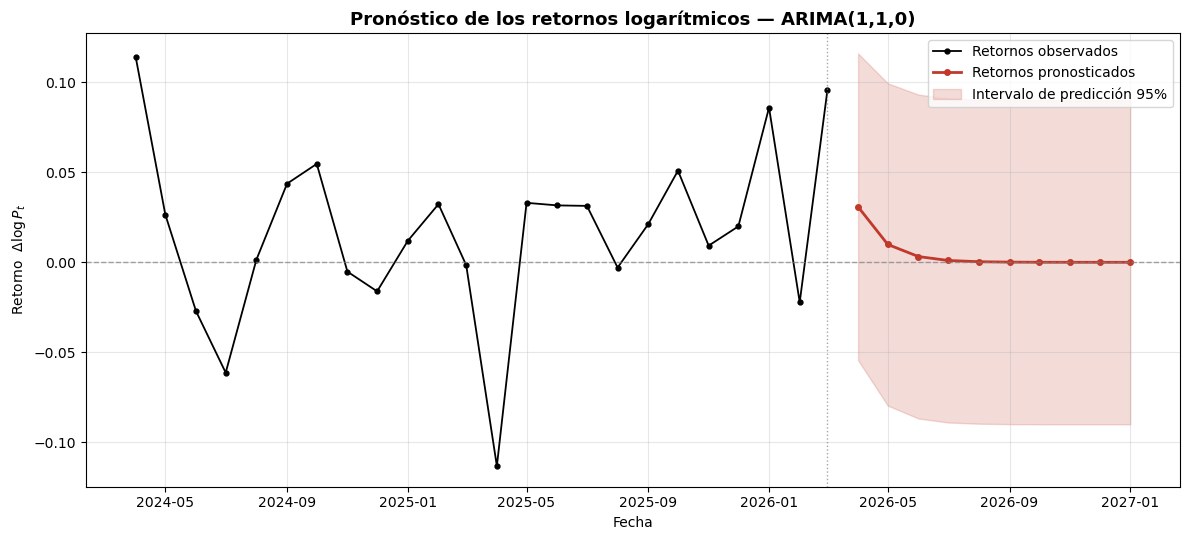

Figura guardada en: c:\poster-main\poster\outputs\figures\15_pronostico_retornos.png


In [37]:
# %% Gráfica del pronóstico de los retornos =================

# Re-carga, estimación y pronóstico de retornos (celda autocontenida)
ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"
aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")
aluminio_log = np.log(aluminio_serie)

modelo_ganador = SARIMAX(
    aluminio_log, order=(1, 1, 0), trend="n",
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=200)

H = 10
a1 = modelo_ganador.params["ar.L1"]
sigma2 = modelo_ganador.params["sigma2"]

fc = modelo_ganador.get_forecast(steps=H)
ultimo_log = pd.Series([aluminio_log.iloc[-1]], index=[aluminio_log.index[-1]])
retornos_fc = pd.concat([ultimo_log, fc.predicted_mean]).diff().dropna()

j = np.arange(1, H + 1)
se_ret = np.sqrt(sigma2 * (1 - a1 ** (2 * j)) / (1 - a1 ** 2))
li_ret = retornos_fc.values - 1.96 * se_ret
ls_ret = retornos_fc.values + 1.96 * se_ret

retornos_obs = aluminio_log.diff().dropna()

# Gráfica
fig, ax = plt.subplots(figsize=(12, 5.5))
hist = retornos_obs.iloc[-24:]   # últimos 24 meses observados
ax.plot(hist.index, hist.values, color="black", linewidth=1.3, marker="o", markersize=3.5,
        label="Retornos observados")
ax.plot(retornos_fc.index, retornos_fc.values, color="#c0392b", linewidth=2.0, marker="o", markersize=4,
        label="Retornos pronosticados")
ax.fill_between(retornos_fc.index, li_ret, ls_ret, color="#c0392b", alpha=0.18,
                label="Intervalo de predicción 95%")
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(aluminio_log.index[-1], color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax.set_title("Pronóstico de los retornos logarítmicos — ARIMA(1,1,0)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"Retorno  $\Delta \log P_t$")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta_fig = FIGURES / "15_pronostico_retornos.png"
plt.savefig(ruta_fig)
plt.show()
print(f"Figura guardada en: {ruta_fig}")